In [1]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("dataset.csv")

/tmp/ipykernel_34888/4165960621.py:5: DtypeWarning: Columns (0: WORKORDERID, 1: CSRNUMBER, 2: CANCELEDDATE, 3: CANCELEDBY, 4: WARD, 5: NEIGHBORHOODNAMES, 6: BID, 7: AWI, 8: EDZ, 9: NIF, 10: ZONING, 11: CFAR, 12: SQUARE, 13: SUFFIX, 14: LOT) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dataset.csv")


In [2]:
# -------------------------
# 1. Gambaran umum data
# -------------------------
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nHead:")
print(df.head())

print("\nSample acak:")
print(df.sample(5, random_state=42))

print("\nInfo:")
print(df.info())

# -------------------------
# 2. Cek missing values
# -------------------------
print("\nMissing values per kolom:")
print(df.isna().sum().sort_values(ascending=False))

print("\nPersentase missing values:")
print((df.isna().sum() / len(df) * 100).sort_values(ascending=False))

# -------------------------
# 3. Cek duplikat
# -------------------------
print("\nJumlah duplikat total:")
print(df.duplicated().sum())

# Kalau mau lihat baris duplikat
duplicates = df[df.duplicated(keep=False)]
print("\nContoh baris duplikat:")
print(duplicates.head(10))

# -------------------------
# 4. Cek tipe data & statistik
# -------------------------
print("\nTipe data:")
print(df.dtypes)

print("\nStatistik numerik:")
print(df.describe())

print("\nStatistik semua kolom:")
print(df.describe(include="all"))

# -------------------------
# 5. Cek jumlah nilai unik
# -------------------------
print("\nJumlah nilai unik per kolom:")
print(df.nunique().sort_values())

# -------------------------
# 6. Lihat distribusi kolom kategorikal
# -------------------------
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    print(f"\nValue counts untuk: {col}")
    print(df[col].value_counts(dropna=False))

# -------------------------
# 7. Cek kolom numerik untuk nilai ekstrem
# -------------------------
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    print(f"\nRingkasan kolom numerik: {col}")
    print(df[col].describe())
    print("Skew:", df[col].skew())


Shape: (1466152, 56)

Columns:
['X', 'Y', 'OBJECTID', 'REQUESTID', 'WORKORDERID', 'CSRNUMBER', 'DESCRIPTION', 'STATUS', 'REQUESTCATEGORY', 'INITIATEDDATE', 'CLOSEDDATE', 'INSPECTIONDATE', 'INSPECTIONCOMPLETE', 'SUBMITTEDTODATE', 'DISPATCHEDTODATE', 'CANCELEDDATE', 'PRIORITY', 'INITIATEDBY', 'SUBMITTEDTO', 'DISPATCHEDTO', 'CLOSEDBY', 'PROJECTNAME', 'ISCANCELED', 'CANCELEDBY', 'ADDRESS', 'FISCALYEAR', 'WARD', 'QUADRANT', 'ZIPCODE', 'ANC', 'SMD', 'NEIGHBORHOODCLUSTERS', 'NEIGHBORHOODNAMES', 'BID', 'AWI', 'EDZ', 'NIF', 'HISTORICDISTRICT', 'ZONING', 'PUD', 'CFAR', 'PSA', 'PD', 'DAYSTOCLOSE', 'DAYSTOINSPECT', 'UPDATEDATE', 'XCOORD', 'YCOORD', 'ONSEGX', 'ONSEGY', 'LONGITUDE', 'LATITUDE', 'SQUARE', 'SUFFIX', 'LOT', 'GlobalID']

Head:
              X             Y  OBJECTID  REQUESTID WORKORDERID    CSRNUMBER  \
0 -8.580576e+06  4.708431e+06         1       1180         NaN  13-00079017   
1 -8.573816e+06  4.716823e+06         2     318742    173022.0  10-00188633   
2 -8.569083e+06  4.707386e+

/tmp/ipykernel_34888/158074104.py:58: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


CSRNUMBER
NaN            464191
15-00109459        20
15-00109429        11
15-00109430        11
15-00108743        10
                ...  
19-00739019         1
19-00750972         1
19-00803391         1
19-00820925         1
19-00774384         1
Name: count, Length: 984222, dtype: int64

Value counts untuk: DESCRIPTION
DESCRIPTION
PARKING METER REQUES    621206
ROADWAY SIGN            129310
STREETLIGHT REPAIR      115402
POTHOLES                 98268
TREE INSPECTION          80009
                         ...  
SIGNS CONFLICTING            1
POLE KNOCKDOWN               1
PUBLIC SPACE - DEFEC         1
PSD                          1
NEW SIGNAL                   1
Name: count, Length: 97, dtype: int64

Value counts untuk: STATUS
STATUS
CLOSED                  1450416
INSPCOMP                   6910
PENDING                    6062
OPEN                       2438
COMPLETE                    154
INSPECTION COMPLETED        145
NaN                          12
GEO ISSUE              

In [3]:
# =========================
# 1. PILIH KOLOM INTI
# Termasuk CLOSEDDATE & STATUS sebagai kolom audit/validasi
# =========================

selected_features = [
    "DESCRIPTION",
    "REQUESTCATEGORY",
    "INITIATEDDATE",
    "ADDRESS",
    "LONGITUDE",
    "LATITUDE",
    "DAYSTOCLOSE",
    "CLOSEDDATE",   # audit: validasi konsistensi DAYSTOCLOSE
    "STATUS"        # audit: konfirmasi apakah kasus memang sudah closed
]

X_core = df[[col for col in selected_features if col in df.columns]].copy()

print("Shape awal X_core:", X_core.shape)

Shape awal X_core: (1466152, 9)


In [4]:
# =========================
# 2. STANDARDISASI FORMAT TEKS
# =========================

text_cols = ["DESCRIPTION", "REQUESTCATEGORY", "ADDRESS"]
for col in text_cols:
    if col in X_core.columns:
        X_core[col] = (
            X_core[col]
            .astype("string")
            .str.strip()
            .str.upper()
            .str.replace(r"\s+", " ", regex=True)
        )


# =========================
# 3. KONVERSI DATETIME
# =========================

# INITIATEDDATE
if "INITIATEDDATE" in X_core.columns:
    X_core["INITIATEDDATE"] = pd.to_datetime(
        X_core["INITIATEDDATE"],
        errors="coerce",
        utc=True
    )

# CLOSEDDATE: format raw terlihat seperti "2024/10/03 23:55:00+00"
if "CLOSEDDATE" in X_core.columns:
    closeddate_raw = X_core["CLOSEDDATE"].astype("string").str.strip()
    closeddate_raw = closeddate_raw.replace({"nan": pd.NA, "None": pd.NA, "NaN": pd.NA, "": pd.NA})

    # parse format utama
    parsed_fixed = pd.to_datetime(
        closeddate_raw,
        format="%Y/%m/%d %H:%M:%S%z",
        errors="coerce"
    )
    # fallback generic untuk format campuran
    parsed_fallback = pd.to_datetime(
        closeddate_raw,
        errors="coerce",
        utc=True
    )

    X_core["CLOSEDDATE"] = parsed_fixed.fillna(parsed_fallback)
    X_core["CLOSEDDATE"] = pd.to_datetime(X_core["CLOSEDDATE"], utc=True, errors="coerce")

    print("CLOSEDDATE parsed     :", X_core["CLOSEDDATE"].notna().sum())
    print("CLOSEDDATE still NaT  :", X_core["CLOSEDDATE"].isna().sum())

CLOSEDDATE parsed     : 1448163
CLOSEDDATE still NaT  : 17989


In [5]:
# =========================
# 4. VALIDASI KOORDINAT
# Koordinat dipertahankan untuk tahap cleaning & near duplicate,
# dapat di-drop di dataset final modeling jika tidak digunakan sebagai fitur
# =========================

if "LONGITUDE" in X_core.columns:
    invalid_lon = (~X_core["LONGITUDE"].between(-180, 180)).sum()
    X_core.loc[~X_core["LONGITUDE"].between(-180, 180), "LONGITUDE"] = np.nan
    print(f"Invalid LONGITUDE set to NaN: {invalid_lon}")

if "LATITUDE" in X_core.columns:
    invalid_lat = (~X_core["LATITUDE"].between(-90, 90)).sum()
    X_core.loc[~X_core["LATITUDE"].between(-90, 90), "LATITUDE"] = np.nan
    print(f"Invalid LATITUDE set to NaN: {invalid_lat}")


# =========================
# 5. HAPUS BARIS PADA KOLOM INTI WAJIB
# =========================

required_cols = ["DESCRIPTION", "INITIATEDDATE"]
before_drop = len(X_core)
X_core = X_core.dropna(subset=[c for c in required_cols if c in X_core.columns])
print(f"Dropped rows (missing required cols): {before_drop - len(X_core)}")


# =========================
# 6. TANGANI MISSING VALUES
# =========================

if "REQUESTCATEGORY" in X_core.columns:
    X_core["REQUESTCATEGORY"] = X_core["REQUESTCATEGORY"].fillna("UNKNOWN")

if "ADDRESS" in X_core.columns:
    X_core["ADDRESS"] = X_core["ADDRESS"].fillna("UNKNOWN")


# =========================
# 7. BERSIHKAN DAYSTOCLOSE
# Nilai negatif → NaN karena tidak logis sebagai durasi
# Nilai 0 DIPERTAHANKAN: berdasarkan audit CLOSEDDATE_RAW,
# DAYSTOCLOSE = 0 merepresentasikan laporan yang ditutup pada hari yang sama
# =========================

if "DAYSTOCLOSE" in X_core.columns:
    neg_count = (X_core["DAYSTOCLOSE"] < 0).sum()
    X_core.loc[X_core["DAYSTOCLOSE"] < 0, "DAYSTOCLOSE"] = np.nan
    print(f"Negative DAYSTOCLOSE converted to NaN: {neg_count}")
    print("Note: DAYSTOCLOSE = 0 tetap dipertahankan sebagai same-day closure")

# =========================
# 8. FILTER & PENGELOMPOKAN DESCRIPTION
# =========================

# Kategori yang DIBUANG karena tidak relevan dengan konteks RT/RW
discard_categories = [
    # Parkir & kendaraan administratif
    "PARKING METER REQUES",
    "PARKING METER REQUEST",
    "RESIDENT PARKING PER",
    "RESIDENT PARKING PERMIT",
    "PARKING - HANDICAP",
    "PARKING-DISABLED",
    "PARKING-HANDICAP",
    "NO PARKING SIGNS",
    "LOADING ZONE",
    "OVER SIZE VEHICLE PER",
    "OVER SIZE VEHICLE PERMIT",
    "MOTOR VEHICLE THEFT",

    # Transportasi publik kota
    "BUS/RAIL ISSUES",
    "BUS AND/OR RAIL ISSU",
    "STREETCAR TRACKS",
    "STRCAR",
    "DC BIKE SHARE",
    "BUS SHELTERS",               
    "PRIORITY BUS STOP PR",
    "PRIORITY STOP SNOW",

    # Administratif & perizinan kota
    "DDOT CITATION",
    "DDOT INQUIRY",
    "DDOT INSPECTION",
    "COMMUNITY MEETINGS",
    "ANC RESOLUTION",
    "RENTAL PERMIT",
    "CONSTRUCTION PERMIT",
    "ROW OCCUPANCY PERMIT",
    "SPECIAL EVENTS COORD",
    "RESIDENTIAL PERMIT -",
    "SCHOOL SUBSIDY",
    "ESCALATED ENGAGEMENT",

    # Program kota — bukan laporan infrastruktur komunitas
    "CHILD SAFETY SEAT PR",
    "SAFE ROUTES TO SCHOO",
    "PEDESTRIAN SAFETY PR",
    "SCHOOL CROSSING GUAR",
    "SPEED STUDY DATA MAP",
    "TRAFFIC CAMERA LOCAT",

    # Traffic signal — diputuskan tidak dimasukkan
    "PUSH BUTTON MALFUNCT",
    "PEDESTRIAN SIGNAL MA",
    "PEDESTRIAN SIGNAL RE",
    "NEW SIGNAL",

    # Infrastruktur kota besar — tidak relevan RT/RW
    "LIGHT-TUNNEL/UNDPASS",         # tidak ada terowongan di RT/RW

    # Kode internal sistem — tidak dikenali
    "PSI",
    "PSD",
    "S0081", "S0361", "S0466", "S0016", "S0082", "S0021",
    "S0381", "S0499", "S0306", "S0460", "S0457", "S0280",
    "S04TP", "S0456", "S0459", "S0371", "S0287",
]

# Mapping ke grup RT/RW
description_remap = {
    # LIGHTING
    "STREETLIGHT REPAIR": "LIGHTING",
    "STREETLIGHT KNOCKDOWN": "LIGHTING",
    "STREETLIGHT INVESTIGATION": "LIGHTING",
    "LIGHT OFFLINE": "LIGHTING",
    "ALLEYLIGHT REPAIR": "LIGHTING",
    "ALLEY LIGHT REPAIR": "LIGHTING",
    "SLREPAIR": "LIGHTING",
    "LIGHT-LIGHT POLE": "LIGHTING",
    "LIGHT-INFRASTRUCTURE": "LIGHTING",
    "LIGHT-OHGS": "LIGHTING",
    "BULB OUT": "LIGHTING",
    "STREET LIGHT MAINTEN": "LIGHTING",
    "FLASHER MALFUNCTION": "LIGHTING",
    "FLASHER MODIFICATION": "LIGHTING",
    "POLE PAINTING": "LIGHTING",
    "POLE KNOCKDOWN": "LIGHTING",

    # ROAD_AND_SIDEWALK
    "POTHOLES": "ROAD_AND_SIDEWALK",
    "ROADWAY REPAIR": "ROAD_AND_SIDEWALK",
    "SIDEWALK REPAIR": "ROAD_AND_SIDEWALK",
    "CURB GUTTER REPAIR": "ROAD_AND_SIDEWALK",
    "ALLEY REPAIR": "ROAD_AND_SIDEWALK",
    "UTILITY REPAIR": "ROAD_AND_SIDEWALK",
    "UTILITY REPAIR MAJOR": "ROAD_AND_SIDEWALK",
    "GUARDRAIL REPAIR": "ROAD_AND_SIDEWALK",
    "DRAIN INLET REPAIR": "ROAD_AND_SIDEWALK",
    "BRIDGE MAINTENANCE": "ROAD_AND_SIDEWALK",
    "BRIDGE MAINTENANCE R": "ROAD_AND_SIDEWALK",
    "CONCRETE ISLAND REPAIR": "ROAD_AND_SIDEWALK",
    "FOOTPATH REPAIR": "ROAD_AND_SIDEWALK",
    "ROADWAY CLEARING": "ROAD_AND_SIDEWALK",
    "STREET REPAIR": "ROAD_AND_SIDEWALK",
    "STREET REPAVING": "ROAD_AND_SIDEWALK",
    "ALLEY REPAVE": "ROAD_AND_SIDEWALK",
    "SIDEWALK NEW": "ROAD_AND_SIDEWALK",
    "PAVE": "ROAD_AND_SIDEWALK",

    # TREES_AND_GREEN_SPACE
    "TREE INSPECTION": "TREES_AND_GREEN_SPACE",
    "TREE PRUNING": "TREES_AND_GREEN_SPACE",
    "TREE REMOVAL": "TREES_AND_GREEN_SPACE",
    "TREE PLANTING": "TREES_AND_GREEN_SPACE",
    "TREE EMERGENCY": "TREES_AND_GREEN_SPACE",
    "ROOT CUTTING": "TREES_AND_GREEN_SPACE",
    "STUMPS": "TREES_AND_GREEN_SPACE",

    # SIGNS_AND_MARKINGS
    "ROADWAY SIGN": "SIGNS_AND_MARKINGS",
    "ROADWAY MARKINGS": "SIGNS_AND_MARKINGS",
    "TRAFFIC SAFETY": "SIGNS_AND_MARKINGS",
    "TRAFFIC CALMING": "SIGNS_AND_MARKINGS",
    "PAVEMENT MARKINGS": "SIGNS_AND_MARKINGS",
    "MARKING INSTALLATION": "SIGNS_AND_MARKINGS",
    "MARKING MODIFICATION": "SIGNS_AND_MARKINGS",
    "MARKING MAINTENANCE": "SIGNS_AND_MARKINGS",
    "MARKING REMOVAL": "SIGNS_AND_MARKINGS",
    "SIGN REPLACE": "SIGNS_AND_MARKINGS",
    "SIGN REMOVAL": "SIGNS_AND_MARKINGS",
    "SIGN NEW": "SIGNS_AND_MARKINGS",
    "SIGN MISSING": "SIGNS_AND_MARKINGS",
    "SIGN TRAFFIC CONTROL": "SIGNS_AND_MARKINGS",
    "SIGNS CONFLICTING": "SIGNS_AND_MARKINGS",

    # TRAFFIC_SIGNAL
    "TRAFFIC SIGNAL MAIN": "TRAFFIC_SIGNAL",
    "TRAFFIC SIGNAL ISSUE": "TRAFFIC_SIGNAL",
    "TRAFFIC CONTROLLER": "TRAFFIC_SIGNAL",

    # PUBLIC_FACILITIES
    "BULK COLLECTION": "PUBLIC_FACILITIES",
    "DIRTY CAN": "PUBLIC_FACILITIES",
    "GRAFFITI REMOVAL": "PUBLIC_FACILITIES",
    "DEAD ANIMAL REMOVAL": "PUBLIC_FACILITIES",
    "ILLEGAL DUMPING": "PUBLIC_FACILITIES",
    "SANITATION ENFORCEMENT": "PUBLIC_FACILITIES",
    "PARKING FACILITY": "PUBLIC_FACILITIES",
    "BENCH MAINTENANCE": "PUBLIC_FACILITIES",
    "FOUNTAIN MAINTENANCE": "PUBLIC_FACILITIES",
    "BICYCLES": "PUBLIC_FACILITIES",          # sepeda terlantar di area komunitas
    "PUBLIC SPACE - OBSTR": "PUBLIC_FACILITIES",
    "PUBLIC SPACE - DEFEC": "PUBLIC_FACILITIES",
    "ABANDONED VEHICLES": "PUBLIC_FACILITIES", # kendaraan rongsokan di komunitas
    "ABANDONED VEHICLE": "PUBLIC_FACILITIES",
    "ABANDONED BIKE": "PUBLIC_FACILITIES",
    "ABANDONED BICYCLE": "PUBLIC_FACILITIES",
    "FOUND PROPERTY": "PUBLIC_FACILITIES",
    "CURBSIDE MGMT ISSUES": "PUBLIC_FACILITIES",
}

before_filter = len(X_core)

# Buang kategori tidak relevan
X_core = X_core[~X_core["DESCRIPTION"].isin(discard_categories)].copy()
print(f"Rows removed (discard_categories): {before_filter - len(X_core)}")

# Buat kolom DESCRIPTION_GROUPED dari remap
X_core["DESCRIPTION_GROUPED"] = X_core["DESCRIPTION"].map(description_remap)

# Isi yang tidak terpetakan dengan OTHER
X_core["DESCRIPTION_GROUPED"] = X_core["DESCRIPTION_GROUPED"].fillna("OTHER")

print("\nDESCRIPTION_GROUPED distribution:")
print(X_core["DESCRIPTION_GROUPED"].value_counts())

# Cek sisa OTHER untuk audit
print("\n=== Sisa isi OTHER ===")
sisa_other = (
    X_core[X_core["DESCRIPTION_GROUPED"] == "OTHER"]["DESCRIPTION"]
    .value_counts()
)
if len(sisa_other) > 0:
    print(sisa_other.to_string())
else:
    print("OTHER sudah kosong.")

Invalid LONGITUDE set to NaN: 0
Invalid LATITUDE set to NaN: 0
Dropped rows (missing required cols): 21
Negative DAYSTOCLOSE converted to NaN: 21
Note: DAYSTOCLOSE = 0 tetap dipertahankan sebagai same-day closure
Rows removed (discard_categories): 635076

DESCRIPTION_GROUPED distribution:
DESCRIPTION_GROUPED
ROAD_AND_SIDEWALK        213674
TREES_AND_GREEN_SPACE    205869
LIGHTING                 184076
SIGNS_AND_MARKINGS       168925
TRAFFIC_SIGNAL            49934
PUBLIC_FACILITIES          8577
Name: count, dtype: int64

=== Sisa isi OTHER ===
OTHER sudah kosong.


In [6]:
# =========================
# 9. NEAR DUPLICATE DETECTION
# =========================

if "DESCRIPTION" in X_core.columns:
    X_core["DESCRIPTION_CLEAN"] = (
        X_core["DESCRIPTION"]
        .astype("string")
        .str.upper()
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

if "INITIATEDDATE" in X_core.columns:
    X_core["INITIATEDDATE_WINDOW"] = X_core["INITIATEDDATE"].dt.floor("D")

if "LATITUDE" in X_core.columns:
    X_core["LATITUDE_ROUND"] = X_core["LATITUDE"].round(4)

if "LONGITUDE" in X_core.columns:
    X_core["LONGITUDE_ROUND"] = X_core["LONGITUDE"].round(4)

near_duplicate_subset = [
    col for col in [
        "DESCRIPTION_CLEAN",
        "INITIATEDDATE_WINDOW",
        "LATITUDE_ROUND",
        "LONGITUDE_ROUND"
    ] if col in X_core.columns
]

near_dup_count = X_core.duplicated(subset=near_duplicate_subset).sum()
print(f"\nNear duplicates detected: {near_dup_count}")

X_core = X_core.drop_duplicates(subset=near_duplicate_subset, keep="first")
print(f"Remaining duplicate check: {X_core.duplicated(subset=near_duplicate_subset).sum()}")


# =========================
# 10. OUTLIER DAYSTOCLOSE — IQR
# Nilai 0 TIDAK dibuang karena merupakan same-day closure yang valid
# =========================

if "DAYSTOCLOSE" in X_core.columns:
    Q1 = X_core["DAYSTOCLOSE"].quantile(0.25)
    Q3 = X_core["DAYSTOCLOSE"].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = X_core["DAYSTOCLOSE"] > upper_bound
    X_core["DAYSTOCLOSE_IS_OUTLIER"] = outlier_mask.astype(int)

    print(f"\nIQR Outlier DAYSTOCLOSE:")
    print(f"  Q1={Q1}, Q3={Q3}, IQR={IQR}, Upper bound={upper_bound}")
    print(f"  Outlier count: {outlier_mask.sum()}")
    print(f"  DAYSTOCLOSE = 0 count (valid same-day): {(X_core['DAYSTOCLOSE'] == 0).sum()}")

    print("\nDaysToClose stats (sebelum drop outlier & NaN):")
    print(X_core["DAYSTOCLOSE"].describe())

# Step 1: drop outlier DAYSTOCLOSE
before = len(X_core)
X_core = X_core[X_core["DAYSTOCLOSE_IS_OUTLIER"] == 0].copy()
print(f"\nRows dropped (outlier DAYSTOCLOSE > {upper_bound}): {before - len(X_core)}")

# Step 2: drop sisa NaN DAYSTOCLOSE (20 baris)
before = len(X_core)
X_core = X_core.dropna(subset=["DAYSTOCLOSE"]).copy()
print(f"Rows dropped (NaN DAYSTOCLOSE): {before - len(X_core)}")

print(f"\nShape setelah drop outlier & NaN DAYSTOCLOSE: {X_core.shape}")

print("\nDaysToClose stats (final):")
print(X_core["DAYSTOCLOSE"].describe())

# =========================
# 11. AUDIT CLOSEDDATE vs DAYSTOCLOSE
# Khusus untuk memeriksa apakah DAYSTOCLOSE = 0 adalah same-day closure
# =========================

if "CLOSEDDATE" in X_core.columns and "INITIATEDDATE" in X_core.columns:
    X_core["INITIATED_DAY"] = X_core["INITIATEDDATE"].dt.floor("D")
    X_core["CLOSED_DAY"] = X_core["CLOSEDDATE"].dt.floor("D")
    X_core["CALCULATED_CLOSE_DAYS"] = (
        X_core["CLOSED_DAY"] - X_core["INITIATED_DAY"]
    ).dt.days

    # Ringkasan audit khusus DAYSTOCLOSE = 0
    zero_close = X_core[X_core["DAYSTOCLOSE"] == 0].copy()
    same_day = zero_close["CALCULATED_CLOSE_DAYS"].eq(0).sum()
    non_missing = zero_close["CALCULATED_CLOSE_DAYS"].notna().sum()

    print(f"\n=== AUDIT: DAYSTOCLOSE == 0 ===")
    print(f"Total rows DAYSTOCLOSE == 0 : {len(zero_close)}")
    print(f"CLOSEDDATE tersedia         : {zero_close['CLOSEDDATE'].notna().sum()}")
    print(f"CALCULATED_CLOSE_DAYS == 0  : {same_day}")
    print(f"Non-missing calculated days : {non_missing}")
    if non_missing > 0:
        print(f"Same-day proportion         : {round(same_day / non_missing, 4)}")

    print("\nCALCULATED_CLOSE_DAYS distribution (DAYSTOCLOSE == 0):")
    print(zero_close["CALCULATED_CLOSE_DAYS"].value_counts(dropna=False).sort_index())


Near duplicates detected: 49033
Remaining duplicate check: 0

IQR Outlier DAYSTOCLOSE:
  Q1=1.0, Q3=126.0, IQR=125.0, Upper bound=313.5
  Outlier count: 119313
  DAYSTOCLOSE = 0 count (valid same-day): 78730

DaysToClose stats (sebelum drop outlier & NaN):
count    782002.000000
mean        181.371792
std         446.572081
min           0.000000
25%           1.000000
50%           6.000000
75%         126.000000
max       35066.000000
Name: DAYSTOCLOSE, dtype: float64

Rows dropped (outlier DAYSTOCLOSE > 313.5): 119313
Rows dropped (NaN DAYSTOCLOSE): 20

Shape setelah drop outlier & NaN DAYSTOCLOSE: (662689, 15)

DaysToClose stats (final):
count    662689.000000
mean         35.949806
std          68.343289
min           0.000000
25%           1.000000
50%           4.000000
75%          27.000000
max         313.000000
Name: DAYSTOCLOSE, dtype: float64

=== AUDIT: DAYSTOCLOSE == 0 ===
Total rows DAYSTOCLOSE == 0 : 78730
CLOSEDDATE tersedia         : 78571
CALCULATED_CLOSE_DAYS == 0

In [7]:
# =========================
# 12. FEATURE ENGINEERING WAKTU
# =========================

if "INITIATEDDATE" in X_core.columns:
    X_core["YEAR"]      = X_core["INITIATEDDATE"].dt.year
    X_core["MONTH"]     = X_core["INITIATEDDATE"].dt.month
    X_core["DAYOFWEEK"] = X_core["INITIATEDDATE"].dt.dayofweek
    X_core["HOUR"]      = X_core["INITIATEDDATE"].dt.hour

if "HOUR" in X_core.columns:
    def map_time_period(hour):
        if pd.isna(hour):
            return np.nan
        elif 5 <= hour < 12:
            return "Morning"
        elif 12 <= hour < 17:
            return "Afternoon"
        elif 17 <= hour < 21:
            return "Evening"
        else:
            return "Night"

    X_core["TIME_PERIOD"] = X_core["HOUR"].apply(map_time_period)


# =========================
# 13. RINGKASAN AKHIR
# =========================

print("\n========== RINGKASAN AKHIR ==========")
print("Shape X_core final:", X_core.shape)
print("\nMissing values per kolom:")
print(X_core.isna().sum())
print("\nTipe data:")
print(X_core.dtypes)
print("\nSample (5 baris acak):")
display(X_core.sample(5, random_state=42))

# ========== SIMPAN HASIL ==========
# X_core.to_csv("dataset_rt_rw_core_clean.csv", index=False)


========== RINGKASAN AKHIR ==========
Shape X_core final: (662689, 23)

Missing values per kolom:
DESCRIPTION                  0
REQUESTCATEGORY              0
INITIATEDDATE                0
ADDRESS                      0
LONGITUDE                    0
LATITUDE                     0
DAYSTOCLOSE                  0
CLOSEDDATE                5853
STATUS                       0
DESCRIPTION_GROUPED          0
DESCRIPTION_CLEAN            0
INITIATEDDATE_WINDOW         0
LATITUDE_ROUND               0
LONGITUDE_ROUND              0
DAYSTOCLOSE_IS_OUTLIER       0
INITIATED_DAY                0
CLOSED_DAY                5853
CALCULATED_CLOSE_DAYS     5853
YEAR                         0
MONTH                        0
DAYOFWEEK                    0
HOUR                         0
TIME_PERIOD                  0
dtype: int64

Tipe data:
DESCRIPTION                            string
REQUESTCATEGORY                        string
INITIATEDDATE             datetime64[us, UTC]
ADDRESS                  

,DESCRIPTION,REQUESTCATEGORY,INITIATEDDATE,ADDRESS,LONGITUDE,LATITUDE,DAYSTOCLOSE,CLOSEDDATE,STATUS,DESCRIPTION_GROUPED,...,LONGITUDE_ROUND,DAYSTOCLOSE_IS_OUTLIER,INITIATED_DAY,CLOSED_DAY,CALCULATED_CLOSE_DAYS,YEAR,MONTH,DAYOFWEEK,HOUR,TIME_PERIOD
1139647,POTHOLES,TOA-S&B,2021-08-25 02:46:29+00:00,"2444 MASSACHUSETTS AVENUE NW,WASHINGTON,DC,USA...",-77.054405,38.914404,3.0,2021-08-27 19:27:36+00:00,CLOSED,ROAD_AND_SIDEWALK,...,-77.0544,0,2021-08-25 00:00:00+00:00,2021-08-27 00:00:00+00:00,2.0,2021,8,2,2,Night
814943,SIDEWALK REPAIR,ASSET MANAGEMENT,2018-06-12 20:42:47+00:00,"1547 9TH STREET NW,WASHINGTON,DC,USA,20001",-77.023969,38.910806,91.0,2018-09-11 13:28:55+00:00,CLOSED,ROAD_AND_SIDEWALK,...,-77.0240,0,2018-06-12 00:00:00+00:00,2018-09-11 00:00:00+00:00,91.0,2018,6,1,20,Evening
1206419,STREETLIGHT REPAIR,STREETLIGHT,2022-07-21 02:01:21+00:00,"4807 43RD PLACE NW,WASHINGTON,DC,USA,20016",-77.084993,38.952451,5.0,2022-07-25 13:20:32+00:00,CLOSED,LIGHTING,...,-77.0850,0,2022-07-21 00:00:00+00:00,2022-07-25 00:00:00+00:00,4.0,2022,7,3,2,Night
1030113,TREE REMOVAL,UFA,2020-08-14 15:41:10+00:00,"3050 MONROE STREET NE,WASHINGTON,DC,USA,20018",-76.965739,38.933066,3.0,2020-08-17 14:54:33+00:00,CLOSED,TREES_AND_GREEN_SPACE,...,-76.9657,0,2020-08-14 00:00:00+00:00,2020-08-17 00:00:00+00:00,3.0,2020,8,4,15,Afternoon
1250522,SLREPAIR,UNKNOWN,2023-02-23 20:06:28+00:00,"1949 U PLACE SE,WASHINGTON,DC,USA,20020",-76.976371,38.865568,1.0,2023-02-24 15:55:04+00:00,CLOSED,LIGHTING,...,-76.9764,0,2023-02-23 00:00:00+00:00,2023-02-24 00:00:00+00:00,1.0,2023,2,3,20,Evening


In [8]:
# =========================
# 14. DROP NaT CLOSEDDATE
# Keputusan: kualitas data lebih penting, baris tanpa CLOSEDDATE dibuang
# =========================

before_drop = len(X_core)
X_core = X_core.dropna(subset=["CLOSEDDATE"]).copy()
print(f"Rows dropped (CLOSEDDATE NaT): {before_drop - len(X_core)}")
print(f"Shape X_core setelah drop NaT CLOSEDDATE: {X_core.shape}")

print("\nMissing values setelah drop:")
print(X_core[["DAYSTOCLOSE", "CLOSEDDATE", "STATUS"]].isna().sum())

Rows dropped (CLOSEDDATE NaT): 5853
Shape X_core setelah drop NaT CLOSEDDATE: (656836, 23)

Missing values setelah drop:
DAYSTOCLOSE    0
CLOSEDDATE     0
STATUS         0
dtype: int64


In [9]:
# =========================
# 15. LAYER DATASET FINAL
# =========================

# Kolom audit — tidak masuk ke X_final
audit_cols = [
    "CLOSEDDATE",
    "STATUS",
    "DESCRIPTION_CLEAN",
    "INITIATEDDATE_WINDOW",
    "LATITUDE_ROUND",
    "LONGITUDE_ROUND",
    "DAYSTOCLOSE_IS_OUTLIER",
    "INITIATED_DAY",
    "CLOSED_DAY",
    "CALCULATED_CLOSE_DAYS",
    "LONGITUDE",
    "LATITUDE",
]

# Outlier sudah dibuang di X_core (step 10), sehingga tidak perlu layer terpisah
feature_cols = [c for c in X_core.columns if c not in audit_cols]


# X_final: dataset bersih siap analisis & modeling
X_final = X_core[feature_cols].copy()

print("\n========== LAYER DATASET ==========")
print(f"X_core  : {X_core.shape}  (master + audit cols, untuk dokumentasi & reproduksi)")
print(f"X_final : {X_final.shape}  (tanpa audit cols & koordinat, siap analisis & modeling)")

print("\nKolom X_final:")
print(list(X_final.columns))

print("\nDAYSTOCLOSE stats X_final:")
print(X_final["DAYSTOCLOSE"].describe())

print("\nMissing values X_final:")
print(X_final.isna().sum())

print("\nSample X_final (5 baris acak):")
display(X_final.sample(5, random_state=42))

# ========== SIMPAN ==========
# X_core.to_csv("X_core_master.csv", index=False)   # master lengkap dengan audit cols
X_final.to_csv("X_final.csv", index=False)         # dataset siap modeling


========== LAYER DATASET ==========
X_core  : (656836, 23)  (master + audit cols, untuk dokumentasi & reproduksi)
X_final : (656836, 11)  (tanpa audit cols & koordinat, siap analisis & modeling)

Kolom X_final:
['DESCRIPTION', 'REQUESTCATEGORY', 'INITIATEDDATE', 'ADDRESS', 'DAYSTOCLOSE', 'DESCRIPTION_GROUPED', 'YEAR', 'MONTH', 'DAYOFWEEK', 'HOUR', 'TIME_PERIOD']

DAYSTOCLOSE stats X_final:
count    656836.000000
mean         35.075966
std          67.444778
min           0.000000
25%           1.000000
50%           4.000000
75%          26.000000
max         313.000000
Name: DAYSTOCLOSE, dtype: float64

Missing values X_final:
DESCRIPTION            0
REQUESTCATEGORY        0
INITIATEDDATE          0
ADDRESS                0
DAYSTOCLOSE            0
DESCRIPTION_GROUPED    0
YEAR                   0
MONTH                  0
DAYOFWEEK              0
HOUR                   0
TIME_PERIOD            0
dtype: int64

Sample X_final (5 baris acak):


,DESCRIPTION,REQUESTCATEGORY,INITIATEDDATE,ADDRESS,DAYSTOCLOSE,DESCRIPTION_GROUPED,YEAR,MONTH,DAYOFWEEK,HOUR,TIME_PERIOD
1396485,LIGHT OFFLINE,STREETLIGHT P3,2025-01-26 14:25:37+00:00,"1527, 16TH STREET NORTHWEST, DUPONT CIRCLE, WA...",2.0,LIGHTING,2025,1,6,14,Afternoon
436524,POTHOLES,TOA-S&B,2014-04-10 12:59:34+00:00,WISCONSIN AVENUE NW AND WESTERN AVENUE NW,3.0,ROAD_AND_SIDEWALK,2014,4,3,12,Afternoon
1236213,SIDEWALK REPAIR,ASSET MANAGEMENT,2022-12-08 17:22:57+00:00,"1215 33RD STREET NW,WASHINGTON,DC,USA,20007",26.0,ROAD_AND_SIDEWALK,2022,12,3,17,Evening
1291567,TREE INSPECTION,UFA,2023-07-30 20:15:52+00:00,"31 4TH AVENUE SW,WASHINGTON,DC,USA,20319",1.0,TREES_AND_GREEN_SPACE,2023,7,6,20,Evening
711783,STREETLIGHT REPAIR,STREETLIGHT,2017-01-04 23:34:15+00:00,"23 58TH STREET SE,WASHINGTON,DC,USA,20019",4.0,LIGHTING,2017,1,2,23,Night


# EDA Data Final

In [10]:
# =========================
# EDA — BLOK 1: STATISTIK DESKRIPTIF
# =========================

print("--- Numerik: DAYSTOCLOSE ---")
print(X_final["DAYSTOCLOSE"].describe())
print(f"  Skewness : {X_final['DAYSTOCLOSE'].skew():.4f}")
print(f"  Kurtosis : {X_final['DAYSTOCLOSE'].kurt():.4f}")
print(f"  Median   : {X_final['DAYSTOCLOSE'].median()}")
print(f"  Mode     : {X_final['DAYSTOCLOSE'].mode()[0]}")

print("\n--- REQUESTCATEGORY (top 15) ---")
print(X_final["REQUESTCATEGORY"].value_counts().head(15))

print("\n--- TIME_PERIOD ---")
print(X_final["TIME_PERIOD"].value_counts())

print("\n--- Rentang INITIATEDDATE ---")
print(f"  Min: {X_final['INITIATEDDATE'].min()}")
print(f"  Max: {X_final['INITIATEDDATE'].max()}")

print("\n--- Distribusi YEAR ---")
print(X_final["YEAR"].value_counts().sort_index())

print("\n--- Distribusi MONTH ---")
print(X_final["MONTH"].value_counts().sort_index())

print("\n--- Distribusi DAYOFWEEK ---")
day_map = {0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"}
print(X_final["DAYOFWEEK"].map(day_map).value_counts())

print("\n--- DESCRIPTION_GROUPED top 15 ---")
print(X_final["DESCRIPTION_GROUPED"].value_counts().head(15))

--- Numerik: DAYSTOCLOSE ---
count    656836.000000
mean         35.075966
std          67.444778
min           0.000000
25%           1.000000
50%           4.000000
75%          26.000000
max         313.000000
Name: DAYSTOCLOSE, dtype: float64
  Skewness : 2.3288
  Kurtosis : 4.5978
  Median   : 4.0
  Mode     : 1.0

--- REQUESTCATEGORY (top 15) ---
REQUESTCATEGORY
UFA                 182267
TOA-S&B              97053
TOA-S&M              85228
STREETLIGHT          82282
TMC                  42421
UNKNOWN              35143
ASSET MANAGEMENT     32321
TOA-CW               27099
STREETLIGHT P3       23040
TOA-SAFETY           20633
STREETLI             13544
TOA-SIOD              4504
TPPA                  3251
SIOD                  3053
CSC                   1928
Name: count, dtype: Int64

--- TIME_PERIOD ---
TIME_PERIOD
Afternoon    243083
Evening      190810
Night        182898
Morning       40045
Name: count, dtype: int64

--- Rentang INITIATEDDATE ---
  Min: 2009-08-25 15:41:51+0

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
SAVE_DPI = 150

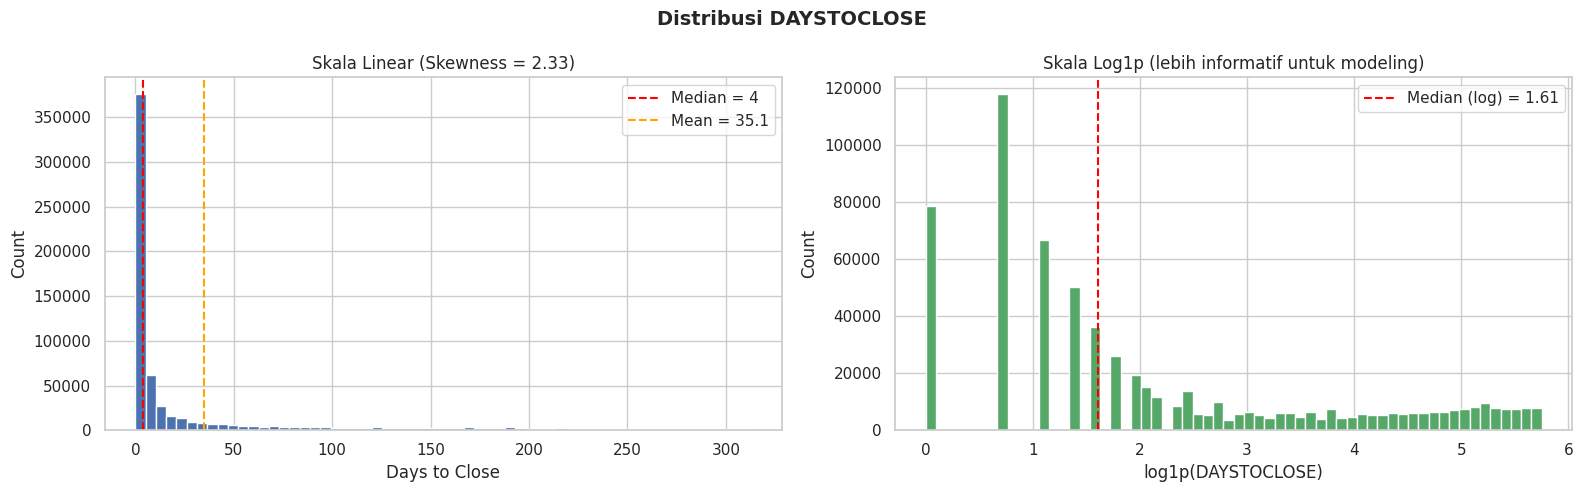

Saved: chart1_daystoclose_dist.png


In [12]:
# =========================
# CHART 1: Distribusi DAYSTOCLOSE (dengan log-scale insight)
# =========================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Distribusi DAYSTOCLOSE", fontsize=14, fontweight="bold")

# 1a. Histogram biasa
axes[0].hist(X_final["DAYSTOCLOSE"], bins=60, color="#4C72B0", edgecolor="white")
axes[0].axvline(X_final["DAYSTOCLOSE"].median(), color="red", linestyle="--",
                linewidth=1.5, label=f"Median = {X_final['DAYSTOCLOSE'].median():.0f}")
axes[0].axvline(X_final["DAYSTOCLOSE"].mean(), color="orange", linestyle="--",
                linewidth=1.5, label=f"Mean = {X_final['DAYSTOCLOSE'].mean():.1f}")
axes[0].set_title("Skala Linear (Skewness = 2.33)")
axes[0].set_xlabel("Days to Close")
axes[0].set_ylabel("Count")
axes[0].legend()

# 1b. Log-transform untuk melihat distribusi yang lebih jelas
log_vals = np.log1p(X_final["DAYSTOCLOSE"])
axes[1].hist(log_vals, bins=60, color="#55A868", edgecolor="white")
axes[1].axvline(np.log1p(X_final["DAYSTOCLOSE"].median()), color="red",
                linestyle="--", linewidth=1.5, label=f"Median (log) = {np.log1p(4):.2f}")
axes[1].set_title("Skala Log1p (lebih informatif untuk modeling)")
axes[1].set_xlabel("log1p(DAYSTOCLOSE)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig("chart1_daystoclose_dist.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()
print("Saved: chart1_daystoclose_dist.png")

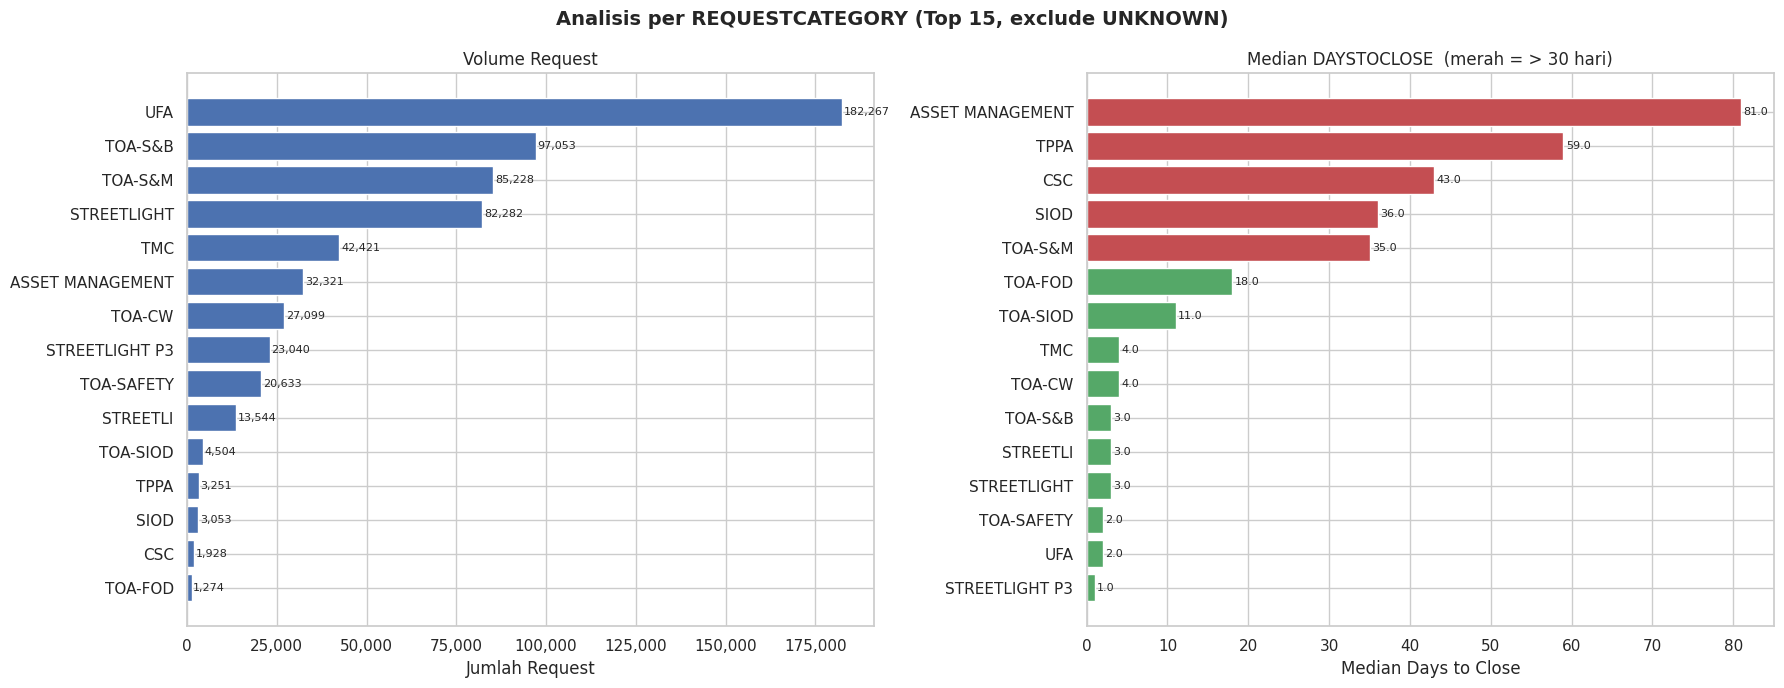

Saved: chart2_requestcategory.png


In [13]:
# =========================
# CHART 2: Volume & Median DAYSTOCLOSE per REQUESTCATEGORY
# =========================

# Ambil top 15, exclude UNKNOWN untuk analisis yang lebih bersih
cat_stats = (
    X_final[X_final["REQUESTCATEGORY"] != "UNKNOWN"]
    .groupby("REQUESTCATEGORY")
    .agg(
        count=("DAYSTOCLOSE", "count"),
        median_days=("DAYSTOCLOSE", "median"),
        mean_days=("DAYSTOCLOSE", "mean"),
    )
    .sort_values("count", ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Analisis per REQUESTCATEGORY (Top 15, exclude UNKNOWN)",
             fontsize=14, fontweight="bold")

# 2a. Volume
bars = axes[0].barh(cat_stats.index[::-1], cat_stats["count"][::-1], color="#4C72B0")
axes[0].set_title("Volume Request")
axes[0].set_xlabel("Jumlah Request")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, val in zip(bars, cat_stats["count"][::-1]):
    axes[0].text(bar.get_width() + 500, bar.get_y() + bar.get_height() / 2,
                 f"{val:,}", va="center", fontsize=8)

# 2b. Median DAYSTOCLOSE
median_sorted = cat_stats["median_days"].reindex(cat_stats.index).sort_values()
colors = ["#C44E52" if v > 30 else "#55A868" for v in median_sorted.values]
bars2 = axes[1].barh(median_sorted.index, median_sorted.values, color=colors)
axes[1].set_title("Median DAYSTOCLOSE  (merah = > 30 hari)")
axes[1].set_xlabel("Median Days to Close")
for bar, val in zip(bars2, median_sorted.values):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("chart2_requestcategory.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()
print("Saved: chart2_requestcategory.png")

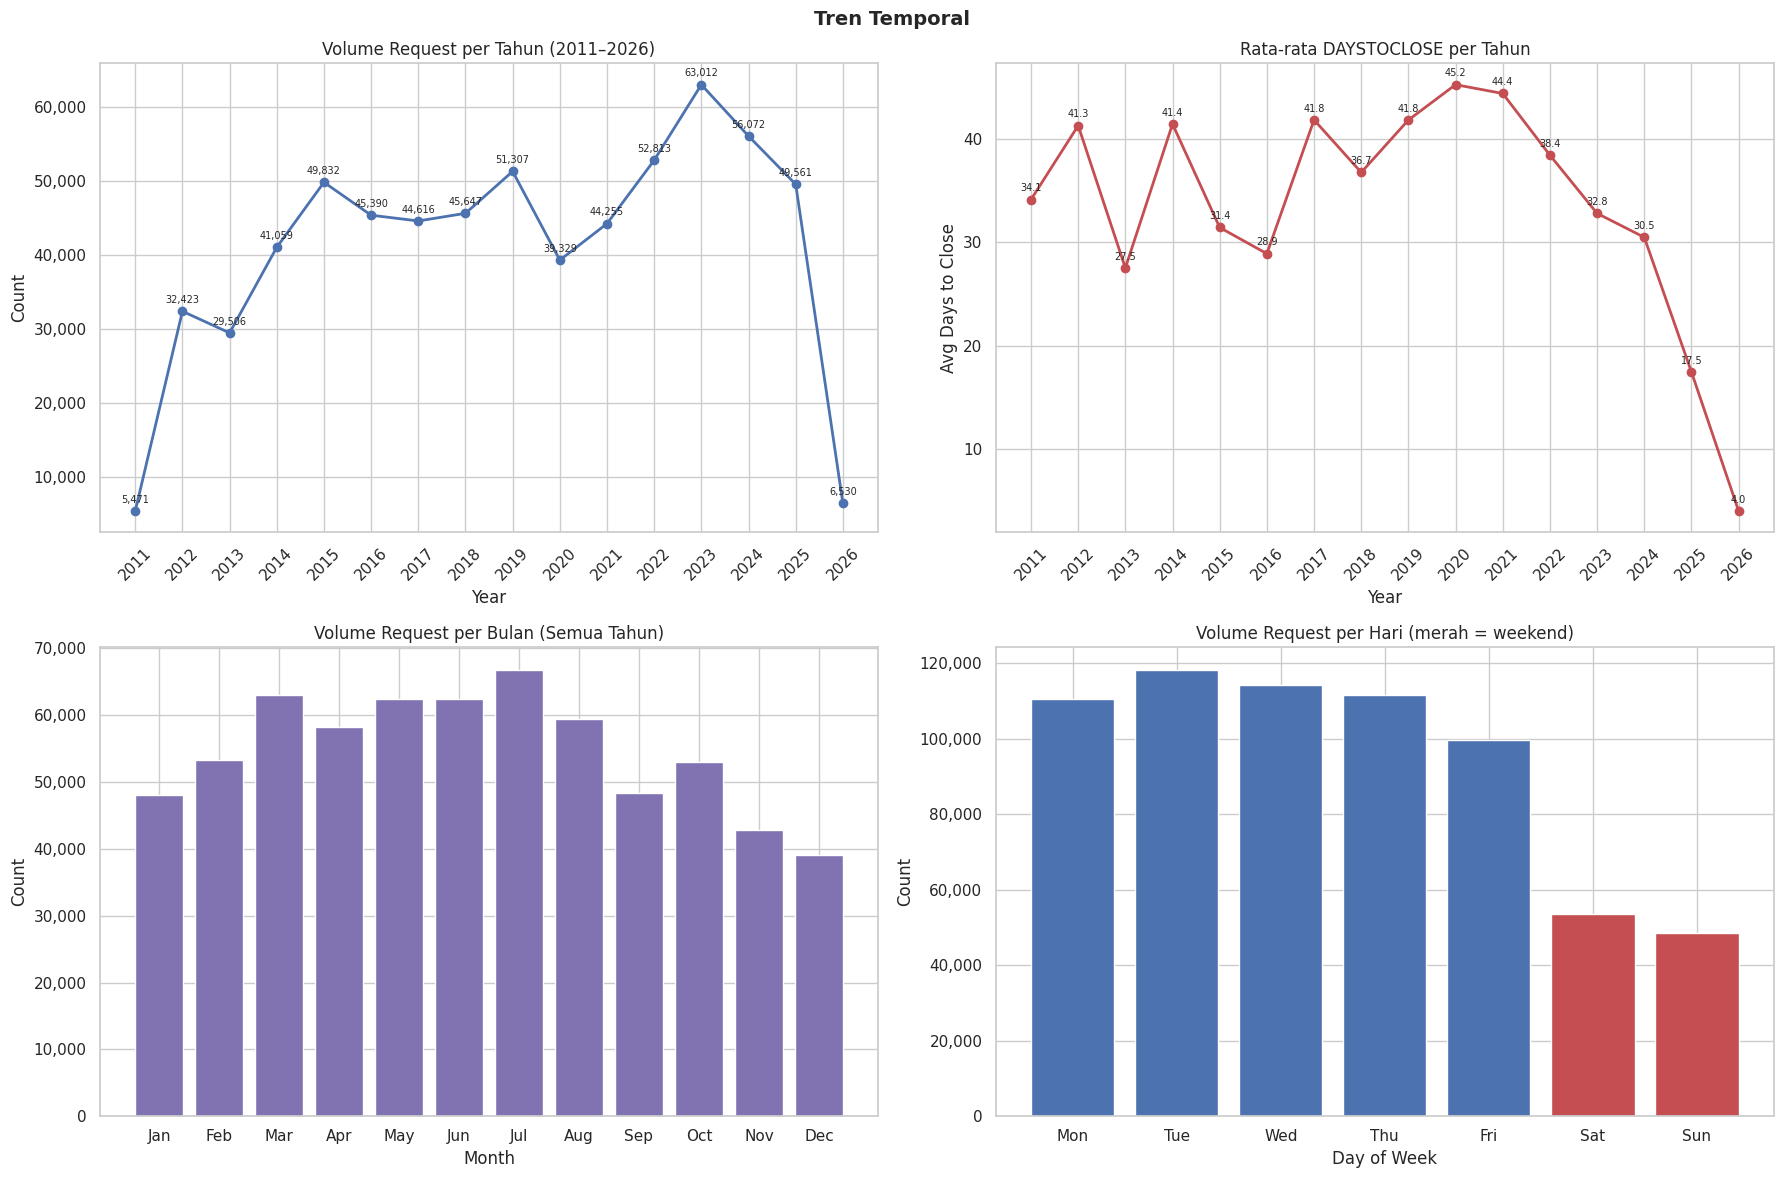

Saved: chart3_temporal.png


In [14]:
# =========================
# CHART 3: Tren Temporal
# Filter tahun 2011+ karena 2009-2010 hanya 13 baris (tidak representatif)
# =========================

df_trend = X_final[X_final["YEAR"] >= 2011].copy()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Tren Temporal", fontsize=14, fontweight="bold")

# 3a. Volume per tahun
year_counts = df_trend["YEAR"].value_counts().sort_index()
axes[0, 0].plot(year_counts.index.astype(str), year_counts.values,
                marker="o", color="#4C72B0", linewidth=2)
axes[0, 0].set_title("Volume Request per Tahun (2011–2026)")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Count")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for x, y in enumerate(year_counts.values):
    axes[0, 0].annotate(f"{y:,}", (x, y), textcoords="offset points",
                        xytext=(0, 6), ha="center", fontsize=7)

# 3b. Rata-rata DAYSTOCLOSE per tahun
avg_days = df_trend.groupby("YEAR")["DAYSTOCLOSE"].mean()
axes[0, 1].plot(avg_days.index.astype(str), avg_days.values,
                marker="o", color="#C44E52", linewidth=2)
axes[0, 1].set_title("Rata-rata DAYSTOCLOSE per Tahun")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Avg Days to Close")
axes[0, 1].tick_params(axis="x", rotation=45)
for x, y in enumerate(avg_days.values):
    axes[0, 1].annotate(f"{y:.1f}", (x, y), textcoords="offset points",
                        xytext=(0, 6), ha="center", fontsize=7)

# 3c. Volume per bulan (agregat semua tahun)
month_counts = df_trend["MONTH"].value_counts().sort_index()
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
axes[1, 0].bar(month_labels, month_counts.values, color="#8172B2")
axes[1, 0].set_title("Volume Request per Bulan (Semua Tahun)")
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Count")
axes[1, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# 3d. Volume per hari dalam seminggu
day_order = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
day_map = {0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"}
dow_counts = df_trend["DAYOFWEEK"].map(day_map).value_counts().reindex(day_order)
bar_colors = ["#4C72B0"] * 5 + ["#C44E52"] * 2  # merah untuk weekend
axes[1, 1].bar(dow_counts.index, dow_counts.values, color=bar_colors)
axes[1, 1].set_title("Volume Request per Hari (merah = weekend)")
axes[1, 1].set_xlabel("Day of Week")
axes[1, 1].set_ylabel("Count")
axes[1, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("chart3_temporal.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()
print("Saved: chart3_temporal.png")

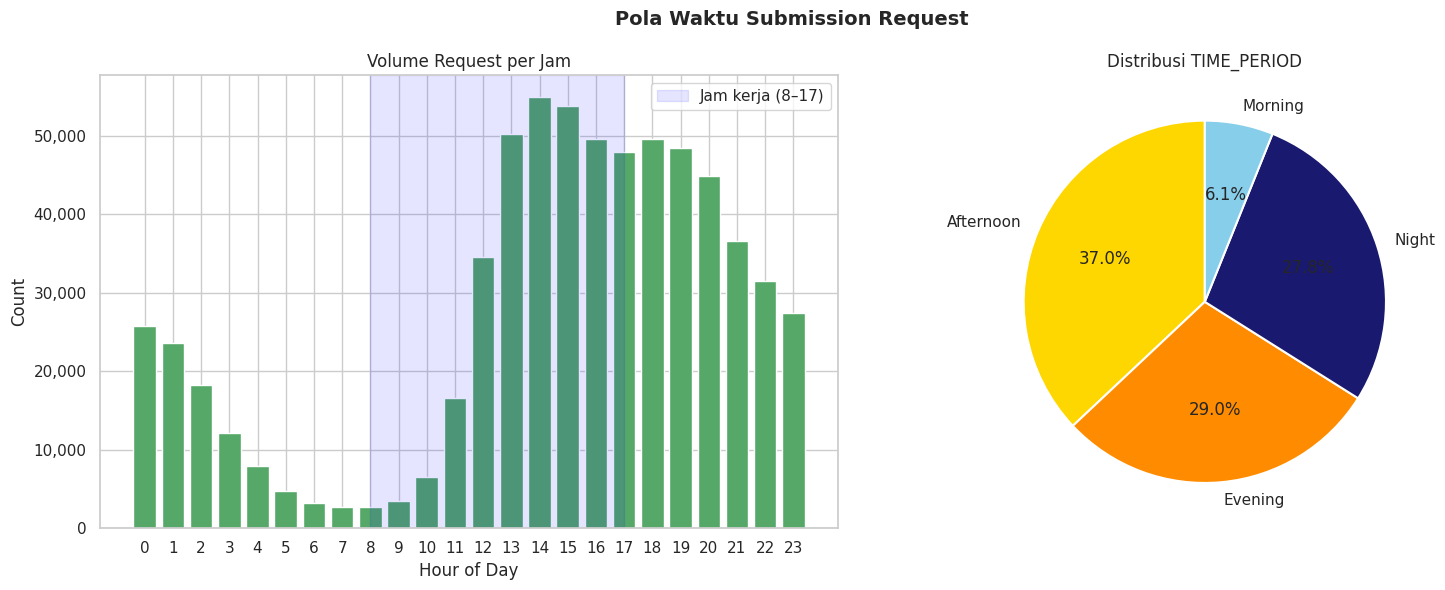

Saved: chart4_jam_timeperiod.png


In [15]:
# =========================
# CHART 4: Pola Submission (HOUR & TIME_PERIOD)
# =========================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Pola Waktu Submission Request", fontsize=14, fontweight="bold")

# 4a. Volume per jam
hour_counts = X_final["HOUR"].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values, color="#55A868", edgecolor="white")
axes[0].set_title("Volume Request per Jam")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Count")
axes[0].set_xticks(range(0, 24))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
# Shade area jam kerja
axes[0].axvspan(8, 17, alpha=0.1, color="blue", label="Jam kerja (8–17)")
axes[0].legend()

# 4b. Pie TIME_PERIOD
tp_counts = X_final["TIME_PERIOD"].value_counts()
palette = ["#FFD700", "#FF8C00", "#191970", "#87CEEB"]  # siang, sore, malam, pagi
axes[1].pie(
    tp_counts.values,
    labels=tp_counts.index,
    autopct="%1.1f%%",
    colors=palette,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
axes[1].set_title("Distribusi TIME_PERIOD")

plt.tight_layout()
plt.savefig("chart4_jam_timeperiod.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()
print("Saved: chart4_jam_timeperiod.png")

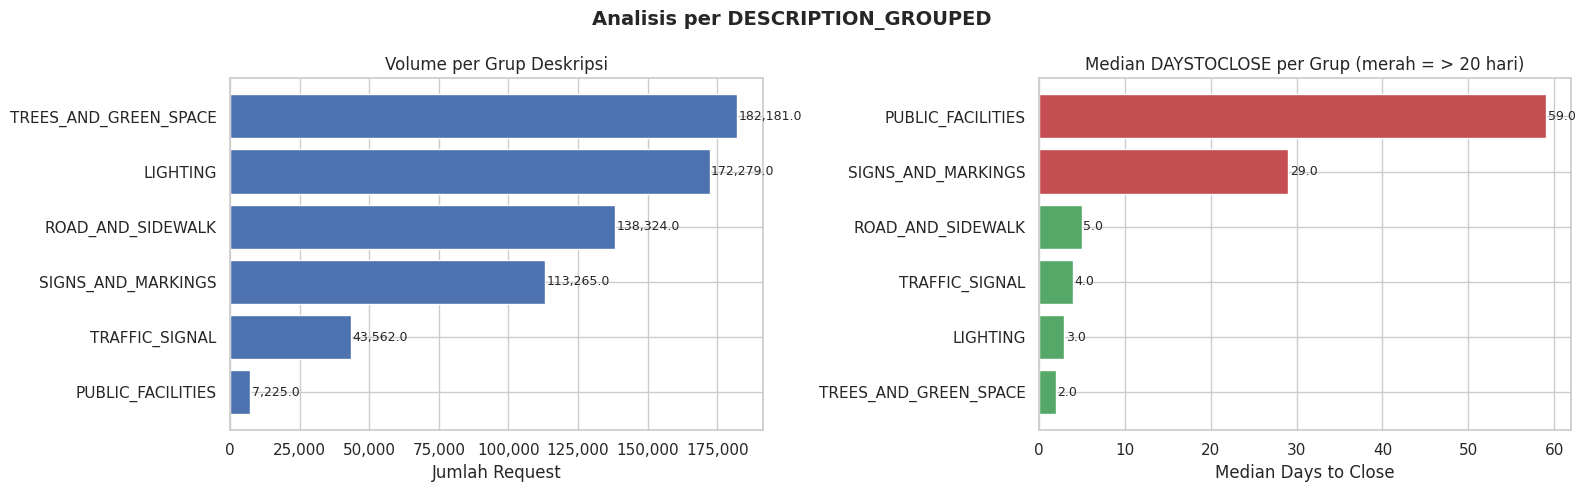

Saved: chart5_description_grouped.png


In [16]:
# =========================
# CHART 5: Volume & Median DAYSTOCLOSE per DESCRIPTION_GROUPED
# =========================

desc_stats = (
    X_final.groupby("DESCRIPTION_GROUPED")
    .agg(count=("DAYSTOCLOSE","count"), median_days=("DAYSTOCLOSE","median"))
    .sort_values("count", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Analisis per DESCRIPTION_GROUPED", fontsize=14, fontweight="bold")

# 5a. Volume
axes[0].barh(desc_stats.index[::-1], desc_stats["count"][::-1], color="#4C72B0")
axes[0].set_title("Volume per Grup Deskripsi")
axes[0].set_xlabel("Jumlah Request")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for i, (idx, row) in enumerate(desc_stats[::-1].iterrows()):
    axes[0].text(row["count"] + 500, i, f"{row['count']:,}", va="center", fontsize=9)

# 5b. Median DAYSTOCLOSE
med_sorted = desc_stats["median_days"].sort_values()
colors = ["#C44E52" if v > 20 else "#55A868" for v in med_sorted.values]
axes[1].barh(med_sorted.index, med_sorted.values, color=colors)
axes[1].set_title("Median DAYSTOCLOSE per Grup (merah = > 20 hari)")
axes[1].set_xlabel("Median Days to Close")
for i, (idx, val) in enumerate(med_sorted.items()):
    axes[1].text(val + 0.2, i, f"{val:.1f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("chart5_description_grouped.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()
print("Saved: chart5_description_grouped.png")

Jumlah titik valid setelah filter: 656,553


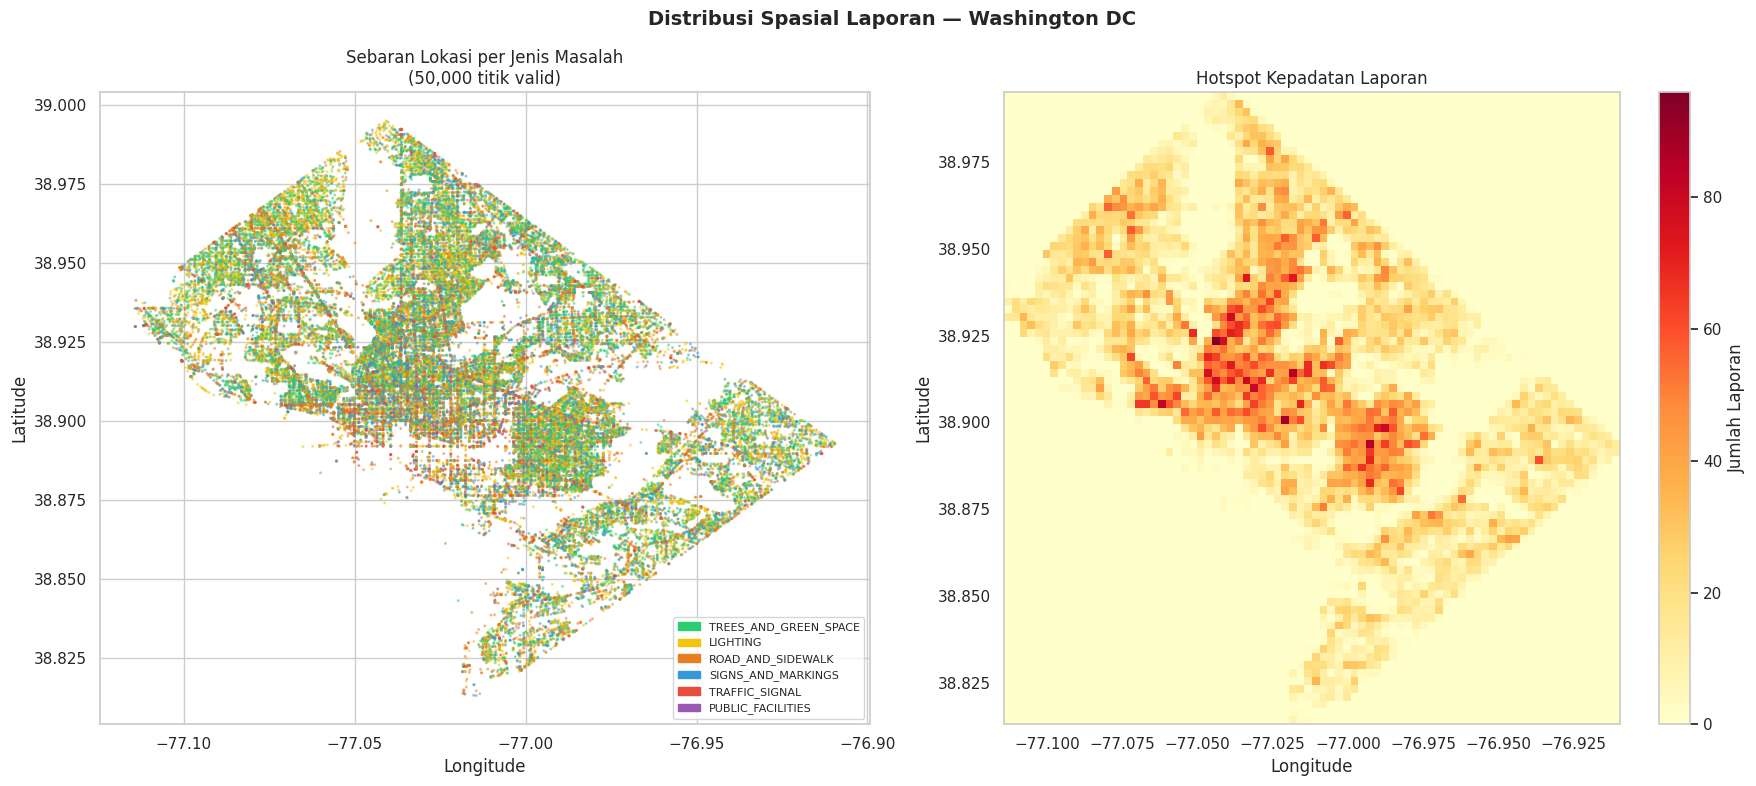

Saved: chart6_spasial_fixed.png


In [17]:
# =========================
# CHART 6: Filter koordinat DC yang valid dulu
# Washington DC: lat 38.8–39.0, lon -77.2 hingga -76.9
# =========================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df_spatial = X_core[["LATITUDE", "LONGITUDE", "DESCRIPTION_GROUPED"]].dropna()

# Filter hanya koordinat yang masuk area DC
df_spatial = df_spatial[
    (df_spatial["LATITUDE"].between(38.7, 39.1)) &
    (df_spatial["LONGITUDE"].between(-77.3, -76.8))
]

print(f"Jumlah titik valid setelah filter: {len(df_spatial):,}")

# Sample maksimal 50.000
if len(df_spatial) > 50000:
    df_spatial = df_spatial.sample(n=50000, random_state=42)

color_map = {
    "TREES_AND_GREEN_SPACE": "#2ecc71",
    "LIGHTING":              "#f1c40f",
    "ROAD_AND_SIDEWALK":     "#e67e22",
    "SIGNS_AND_MARKINGS":    "#3498db",
    "TRAFFIC_SIGNAL":        "#e74c3c",
    "PUBLIC_FACILITIES":     "#9b59b6",
}
colors = df_spatial["DESCRIPTION_GROUPED"].map(color_map).fillna("#95a5a6")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Distribusi Spasial Laporan — Washington DC", 
             fontsize=14, fontweight="bold")

# Panel kiri: scatter per kategori
axes[0].scatter(
    df_spatial["LONGITUDE"], df_spatial["LATITUDE"],
    c=colors, s=1.5, alpha=0.4
)
axes[0].set_title(f"Sebaran Lokasi per Jenis Masalah\n({len(df_spatial):,} titik valid)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
legend_patches = [
    mpatches.Patch(color=v, label=k) for k, v in color_map.items()
]
axes[0].legend(handles=legend_patches, fontsize=8, loc="lower right")

# Panel kanan: heatmap kepadatan
h = axes[1].hist2d(
    df_spatial["LONGITUDE"], df_spatial["LATITUDE"],
    bins=80, cmap="YlOrRd"
)
plt.colorbar(h[3], ax=axes[1], label="Jumlah Laporan")
axes[1].set_title("Hotspot Kepadatan Laporan")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.tight_layout()
plt.savefig("chart6_spasial_fixed.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: chart6_spasial_fixed.png")

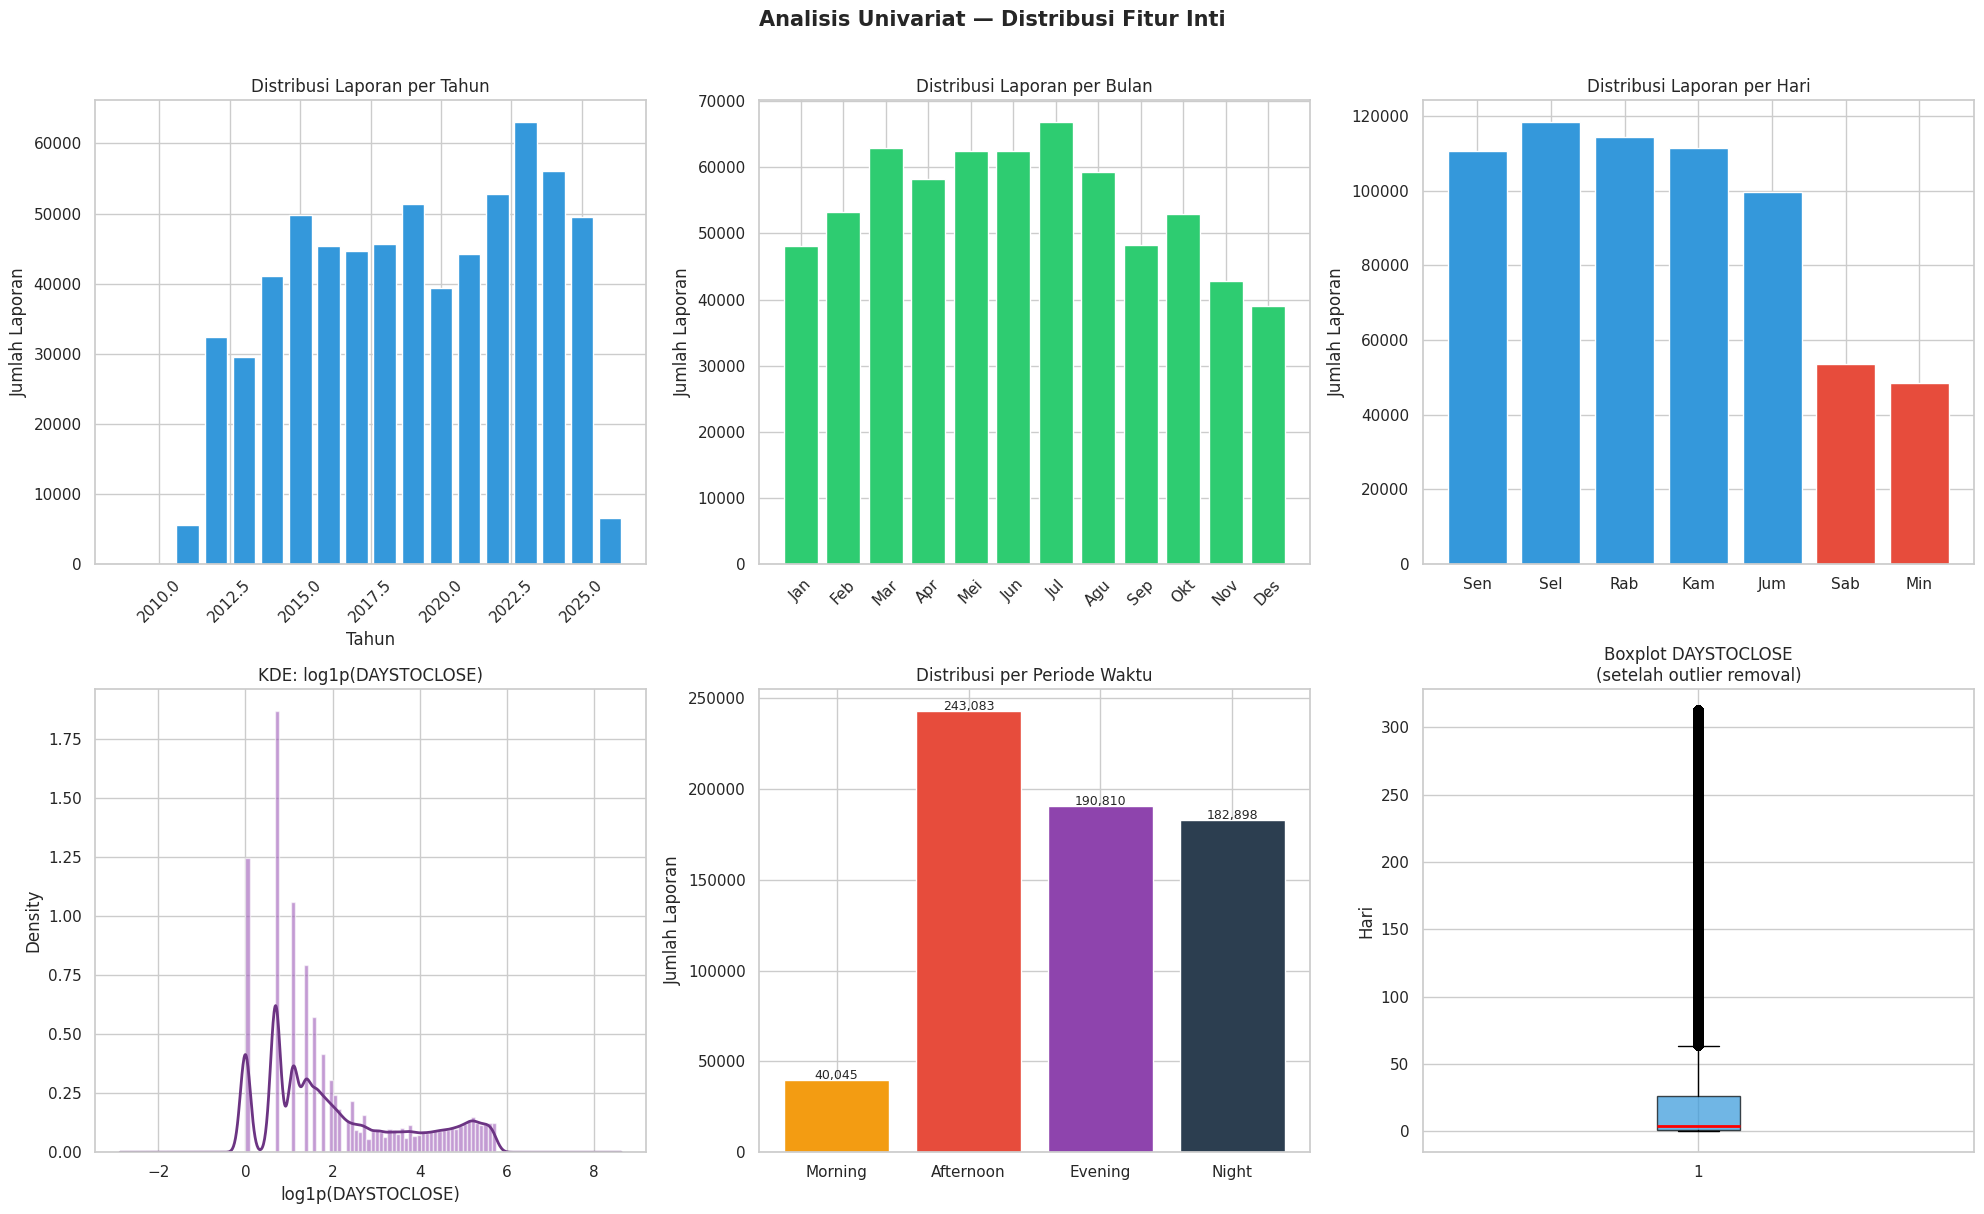

Saved: chart7_univariat_lanjutan.png


In [18]:
# =============================================
# ANALISIS UNIVARIAT
# =============================================

SAVE_DPI = 150
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Analisis Univariat — Distribusi Fitur Inti', 
             fontsize=15, fontweight='bold', y=1.01)

# 1. Distribusi YEAR
year_counts = X_final['YEAR'].value_counts().sort_index()
axes[0,0].bar(year_counts.index, year_counts.values, color='#3498db', edgecolor='white')
axes[0,0].set_title('Distribusi Laporan per Tahun')
axes[0,0].set_xlabel('Tahun')
axes[0,0].set_ylabel('Jumlah Laporan')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Distribusi MONTH
month_counts = X_final['MONTH'].value_counts().sort_index()
month_labels = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']
axes[0,1].bar(range(1,13), month_counts.values, color='#2ecc71', edgecolor='white')
axes[0,1].set_xticks(range(1,13))
axes[0,1].set_xticklabels(month_labels, rotation=45)
axes[0,1].set_title('Distribusi Laporan per Bulan')
axes[0,1].set_ylabel('Jumlah Laporan')

# 3. Distribusi DAYOFWEEK
day_counts = X_final['DAYOFWEEK'].value_counts().sort_index()
day_labels = ['Sen','Sel','Rab','Kam','Jum','Sab','Min']
colors_day = ['#3498db']*5 + ['#e74c3c']*2
axes[0,2].bar(range(7), day_counts.values, color=colors_day, edgecolor='white')
axes[0,2].set_xticks(range(7))
axes[0,2].set_xticklabels(day_labels)
axes[0,2].set_title('Distribusi Laporan per Hari')
axes[0,2].set_ylabel('Jumlah Laporan')

# 4. KDE DAYSTOCLOSE (log1p)
log_vals = np.log1p(X_final['DAYSTOCLOSE'].dropna())
axes[1,0].hist(log_vals, bins=60, color='#9b59b6', edgecolor='white', density=True, alpha=0.6)
log_vals.plot.kde(ax=axes[1,0], color='#6c3483', linewidth=2)
axes[1,0].set_title('KDE: log1p(DAYSTOCLOSE)')
axes[1,0].set_xlabel('log1p(DAYSTOCLOSE)')
axes[1,0].set_ylabel('Density')

# 5. Distribusi TIME_PERIOD
tp_order = ['Morning', 'Afternoon', 'Evening', 'Night']
tp_counts = X_final['TIME_PERIOD'].value_counts().reindex(tp_order)
colors_tp = ['#f39c12','#e74c3c','#8e44ad','#2c3e50']
axes[1,1].bar(tp_order, tp_counts.values, color=colors_tp, edgecolor='white')
for i, v in enumerate(tp_counts.values):
    axes[1,1].text(i, v + 500, f'{v:,}', ha='center', fontsize=9)
axes[1,1].set_title('Distribusi per Periode Waktu')
axes[1,1].set_ylabel('Jumlah Laporan')

# 6. Boxplot DAYSTOCLOSE — overview
axes[1,2].boxplot(X_final['DAYSTOCLOSE'].dropna(), vert=True,
                  patch_artist=True,
                  boxprops=dict(facecolor='#3498db', alpha=0.7),
                  medianprops=dict(color='red', linewidth=2))
axes[1,2].set_title('Boxplot DAYSTOCLOSE\n(setelah outlier removal)')
axes[1,2].set_ylabel('Hari')
axes[1,2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}'))

plt.tight_layout()
plt.savefig('chart7_univariat_lanjutan.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print("Saved: chart7_univariat_lanjutan.png")

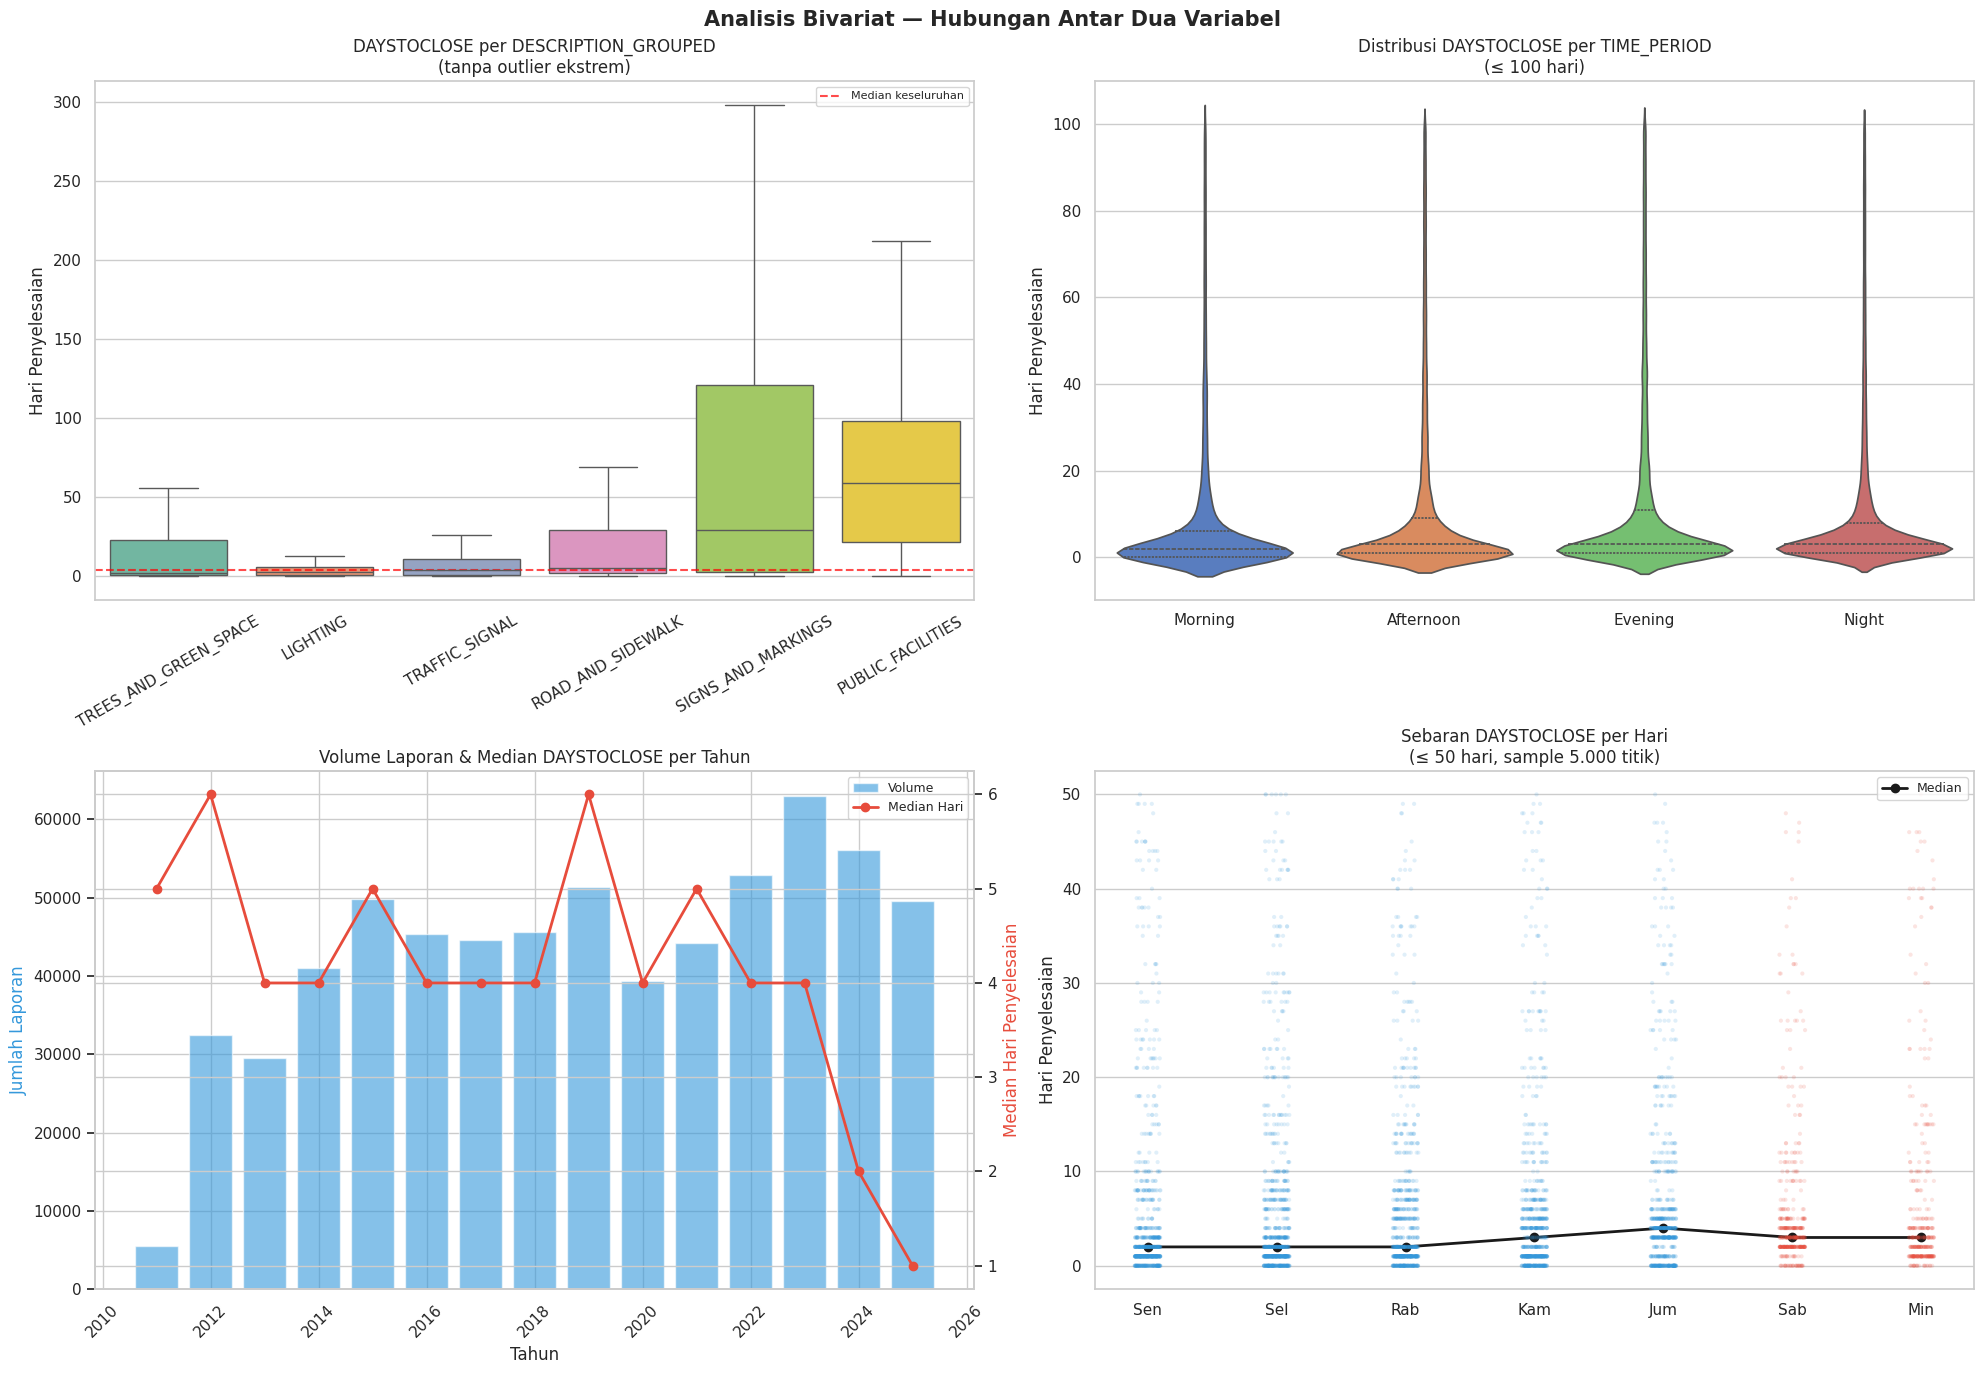

Saved: chart8_bivariat.png


In [19]:
# =============================================
# ANALISIS BIVARIAT
# =============================================

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('Analisis Bivariat — Hubungan Antar Dua Variabel', 
             fontsize=15, fontweight='bold')

# 1. Boxplot DAYSTOCLOSE per DESCRIPTION_GROUPED
order_desc = X_final.groupby('DESCRIPTION_GROUPED')['DAYSTOCLOSE'].median().sort_values().index
sns.boxplot(
    data=X_final,
    x='DESCRIPTION_GROUPED', y='DAYSTOCLOSE',
    order=order_desc,
    palette='Set2',
    ax=axes[0,0],
    showfliers=False  # sembunyikan outlier agar chart lebih bersih
)
axes[0,0].set_title('DAYSTOCLOSE per DESCRIPTION_GROUPED\n(tanpa outlier ekstrem)')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Hari Penyelesaian')
axes[0,0].tick_params(axis='x', rotation=30)
axes[0,0].axhline(y=X_final['DAYSTOCLOSE'].median(), 
                   color='red', linestyle='--', alpha=0.7, label='Median keseluruhan')
axes[0,0].legend(fontsize=8)

# 2. Violin plot DAYSTOCLOSE per TIME_PERIOD
tp_order = ['Morning', 'Afternoon', 'Evening', 'Night']
sns.violinplot(
    data=X_final[X_final['DAYSTOCLOSE'] <= 100],  # filter agar violin terbaca
    x='TIME_PERIOD', y='DAYSTOCLOSE',
    order=tp_order,
    palette='muted',
    ax=axes[0,1],
    inner='quartile'
)
axes[0,1].set_title('Distribusi DAYSTOCLOSE per TIME_PERIOD\n(≤ 100 hari)')
axes[0,1].set_xlabel('')
axes[0,1].set_ylabel('Hari Penyelesaian')

# 3. Bar + line: Volume & Median DAYSTOCLOSE per YEAR
yearly = X_final.groupby('YEAR').agg(
    volume=('DAYSTOCLOSE', 'count'),
    median_days=('DAYSTOCLOSE', 'median')
).reset_index()
yearly = yearly[yearly['YEAR'].between(2011, 2025)]  # exclude anomali 2026

ax3a = axes[1,0]
ax3b = ax3a.twinx()
ax3a.bar(yearly['YEAR'], yearly['volume'], color='#3498db', alpha=0.6, label='Volume')
ax3b.plot(yearly['YEAR'], yearly['median_days'], color='#e74c3c', 
          marker='o', linewidth=2, label='Median Hari')
ax3a.set_title('Volume Laporan & Median DAYSTOCLOSE per Tahun')
ax3a.set_xlabel('Tahun')
ax3a.set_ylabel('Jumlah Laporan', color='#3498db')
ax3b.set_ylabel('Median Hari Penyelesaian', color='#e74c3c')
ax3a.tick_params(axis='x', rotation=45)
lines1, labels1 = ax3a.get_legend_handles_labels()
lines2, labels2 = ax3b.get_legend_handles_labels()
ax3a.legend(lines1+lines2, labels1+labels2, fontsize=9)

# 4. Strip plot DAYSTOCLOSE per DAYOFWEEK (sample)
day_labels_map = {0:'Sen',1:'Sel',2:'Rab',3:'Kam',4:'Jum',5:'Sab',6:'Min'}
sample_df = X_final[X_final['DAYSTOCLOSE'] <= 50].sample(5000, random_state=42).copy()
sample_df['DAY_LABEL'] = sample_df['DAYOFWEEK'].map(day_labels_map)
day_order = ['Sen','Sel','Rab','Kam','Jum','Sab','Min']
sns.stripplot(
    data=sample_df,
    x='DAY_LABEL', y='DAYSTOCLOSE',
    order=day_order,
    alpha=0.15, size=3,
    palette=['#3498db']*5 + ['#e74c3c']*2,
    ax=axes[1,1]
)
# Overlay median
medians = sample_df.groupby('DAY_LABEL')['DAYSTOCLOSE'].median().reindex(day_order)
axes[1,1].plot(range(7), medians.values, 'ko-', linewidth=2, markersize=6, label='Median')
axes[1,1].set_title('Sebaran DAYSTOCLOSE per Hari\n(≤ 50 hari, sample 5.000 titik)')
axes[1,1].set_xlabel('')
axes[1,1].set_ylabel('Hari Penyelesaian')
axes[1,1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('chart8_bivariat.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print("Saved: chart8_bivariat.png")

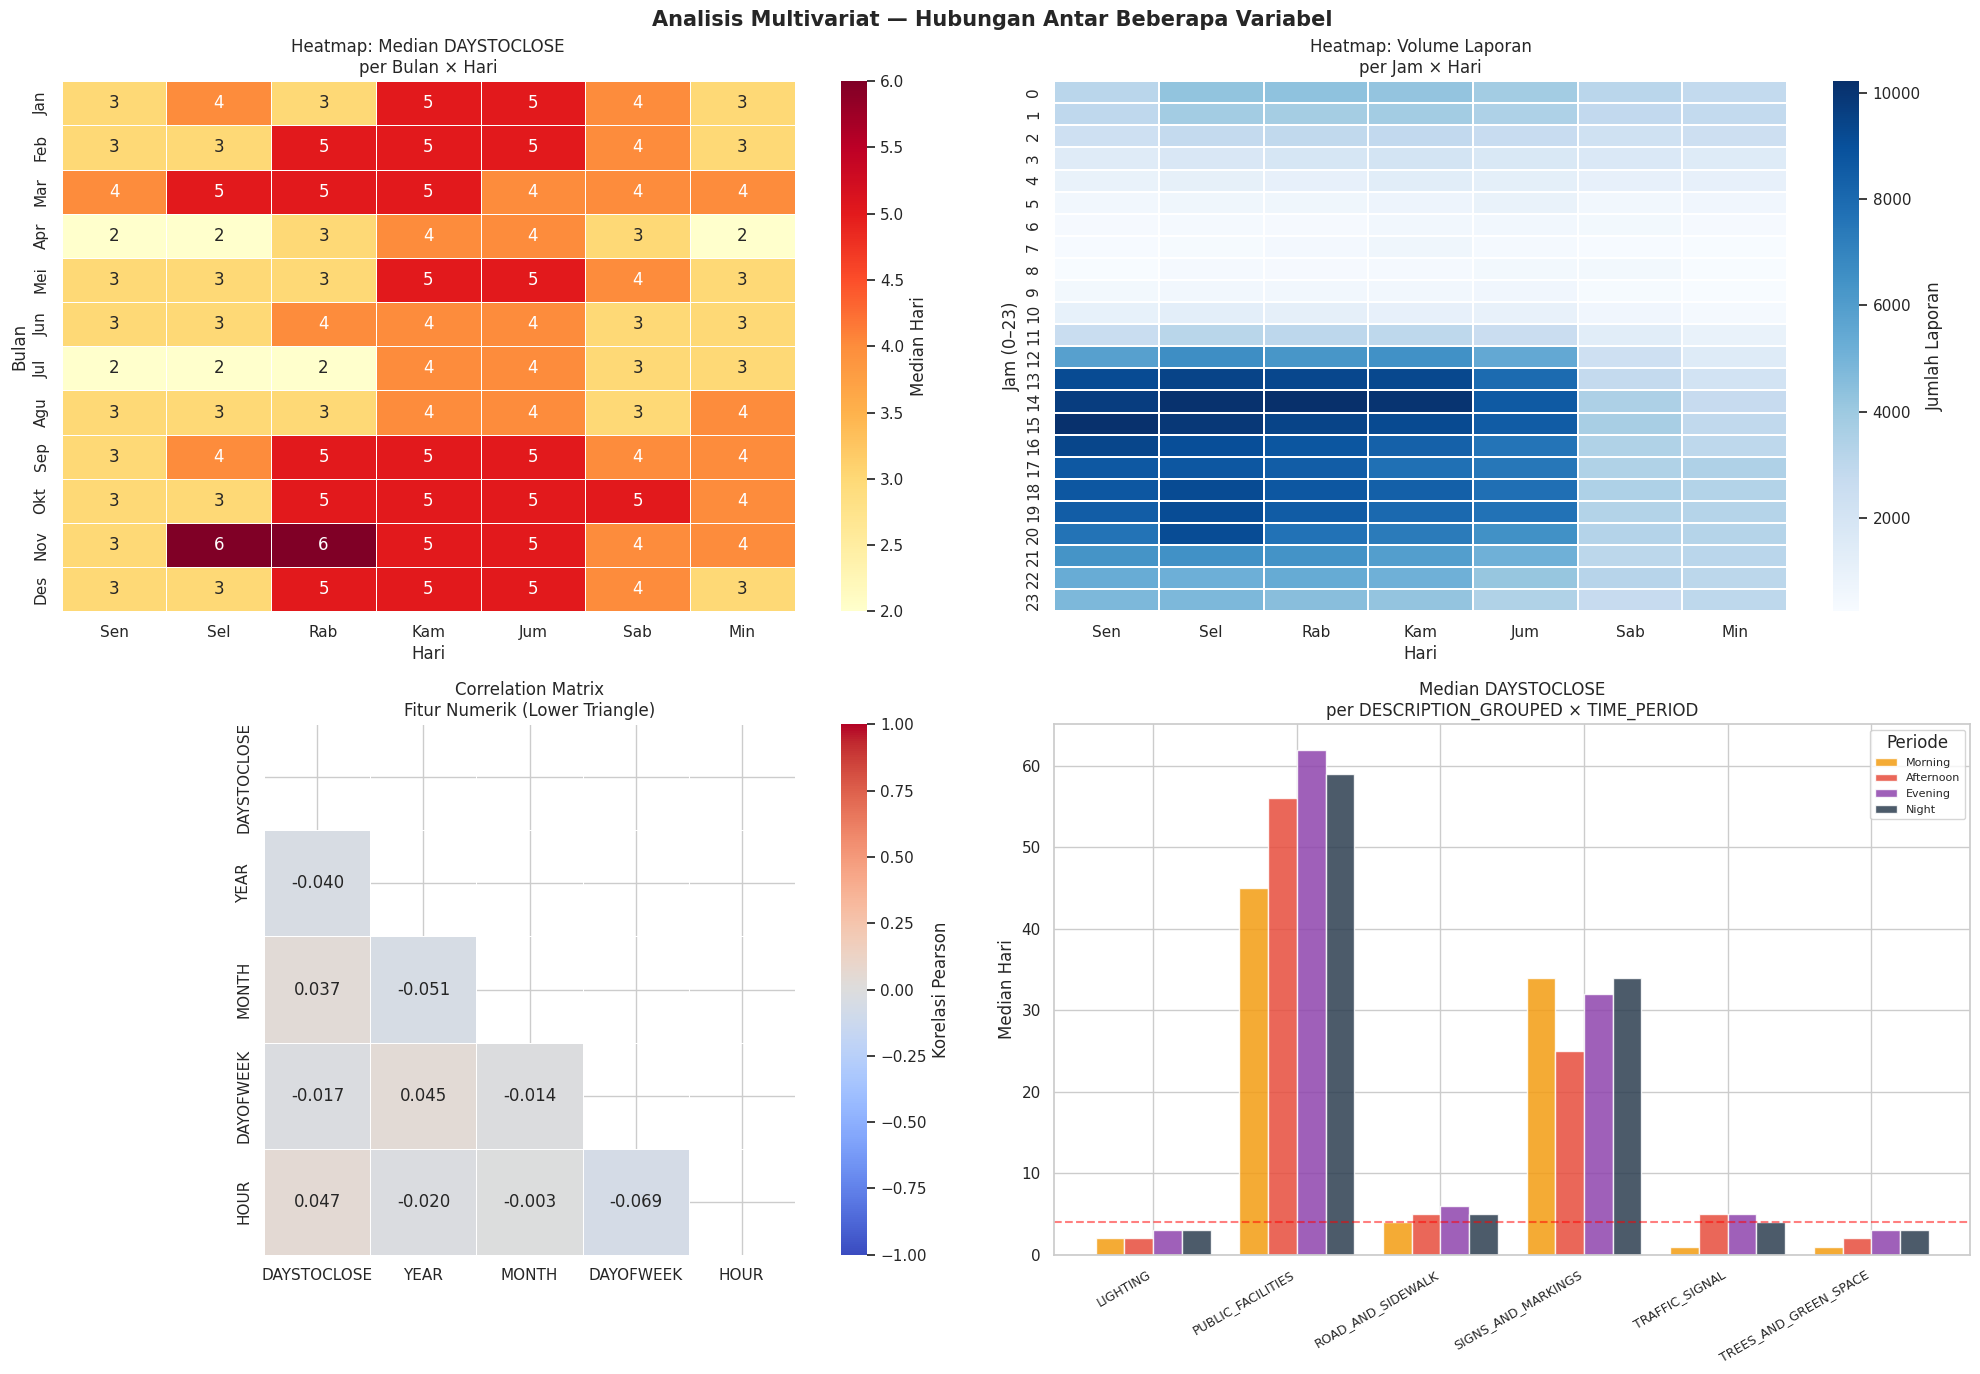

Saved: chart9_multivariat.png


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('Analisis Multivariat — Hubungan Antar Beberapa Variabel', 
             fontsize=15, fontweight='bold')

# 1. Heatmap: Median DAYSTOCLOSE per MONTH x DAYOFWEEK
pivot_heatmap = X_final.pivot_table(
    values='DAYSTOCLOSE',
    index='MONTH',
    columns='DAYOFWEEK',
    aggfunc='median'
)
pivot_heatmap.columns = ['Sen','Sel','Rab','Kam','Jum','Sab','Min']
pivot_heatmap.index = ['Jan','Feb','Mar','Apr','Mei','Jun',
                        'Jul','Agu','Sep','Okt','Nov','Des']
sns.heatmap(
    pivot_heatmap,
    annot=True, fmt='.0f',
    cmap='YlOrRd',
    ax=axes[0,0],
    linewidths=0.5,
    cbar_kws={'label': 'Median Hari'}
)
axes[0,0].set_title('Heatmap: Median DAYSTOCLOSE\nper Bulan × Hari')
axes[0,0].set_xlabel('Hari')
axes[0,0].set_ylabel('Bulan')

# 2. Heatmap: Volume Laporan per HOUR x DAYOFWEEK
pivot_vol = X_final.pivot_table(
    values='DAYSTOCLOSE',
    index='HOUR',
    columns='DAYOFWEEK',
    aggfunc='count'
)
pivot_vol.columns = ['Sen','Sel','Rab','Kam','Jum','Sab','Min']
sns.heatmap(
    pivot_vol,
    cmap='Blues',
    ax=axes[0,1],
    linewidths=0.3,
    cbar_kws={'label': 'Jumlah Laporan'}
)
axes[0,1].set_title('Heatmap: Volume Laporan\nper Jam × Hari')
axes[0,1].set_xlabel('Hari')
axes[0,1].set_ylabel('Jam (0–23)')

# 3. Correlation Matrix — Fitur Numerik
num_cols = ['DAYSTOCLOSE', 'YEAR', 'MONTH', 'DAYOFWEEK', 'HOUR']
corr_matrix = X_final[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    ax=axes[1,0],
    linewidths=0.5,
    square=True,
    cbar_kws={'label': 'Korelasi Pearson'}
)
axes[1,0].set_title('Correlation Matrix\nFitur Numerik (Lower Triangle)')

# 4. Grouped bar: Median DAYSTOCLOSE per DESCRIPTION_GROUPED x TIME_PERIOD
pivot_group = X_final.pivot_table(
    values='DAYSTOCLOSE',
    index='DESCRIPTION_GROUPED',
    columns='TIME_PERIOD',
    aggfunc='median'
)
tp_cols = [c for c in ['Morning','Afternoon','Evening','Night'] if c in pivot_group.columns]
pivot_group = pivot_group[tp_cols]

x_pos = np.arange(len(pivot_group))
width = 0.2
tp_colors = {'Morning':'#f39c12','Afternoon':'#e74c3c','Evening':'#8e44ad','Night':'#2c3e50'}

for i, col in enumerate(tp_cols):
    axes[1,1].bar(x_pos + i*width, pivot_group[col], width=width, 
                  label=col, color=tp_colors.get(col, '#95a5a6'), alpha=0.85,
                  edgecolor='white')

axes[1,1].set_xticks(x_pos + width * (len(tp_cols)-1)/2)
axes[1,1].set_xticklabels(pivot_group.index, rotation=30, ha='right', fontsize=9)
axes[1,1].set_title('Median DAYSTOCLOSE\nper DESCRIPTION_GROUPED × TIME_PERIOD')
axes[1,1].set_ylabel('Median Hari')
axes[1,1].legend(title='Periode', fontsize=8)
axes[1,1].axhline(y=X_final['DAYSTOCLOSE'].median(), 
                   color='red', linestyle='--', alpha=0.5, label='Median overall')

plt.tight_layout()
plt.savefig('chart9_multivariat.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print("Saved: chart9_multivariat.png")

In [21]:
print("=" * 60)
print("RINGKASAN ANALISIS UNIVARIAT, BIVARIAT, MULTIVARIAT")
print("=" * 60)

print("\n--- UNIVARIAT ---")
print(f"Distribusi YEAR: {X_final['YEAR'].min()} – {X_final['YEAR'].max()}")
print(f"Bulan tersibuk : {X_final['MONTH'].value_counts().idxmax()} "
      f"({X_final['MONTH'].value_counts().max():,} laporan)")
print(f"TIME_PERIOD dominan: {X_final['TIME_PERIOD'].value_counts().idxmax()} "
      f"({X_final['TIME_PERIOD'].value_counts().max() / len(X_final) * 100:.1f}%)")

print("\n--- BIVARIAT ---")
for grp, med in X_final.groupby('DESCRIPTION_GROUPED')['DAYSTOCLOSE'].median().sort_values().items():
    print(f"  {grp:<25} median: {med:.0f} hari")

print("\n--- MULTIVARIAT ---")
print("Korelasi terhadap DAYSTOCLOSE:")
num_cols = ['DAYSTOCLOSE','YEAR','MONTH','DAYOFWEEK','HOUR']
corr_with_target = X_final[num_cols].corr()['DAYSTOCLOSE'].drop('DAYSTOCLOSE').sort_values()
for col, val in corr_with_target.items():
    print(f"  {col:<15} r = {val:.4f}")

RINGKASAN ANALISIS UNIVARIAT, BIVARIAT, MULTIVARIAT

--- UNIVARIAT ---
Distribusi YEAR: 2009 – 2026
Bulan tersibuk : 7 (66,821 laporan)
TIME_PERIOD dominan: Afternoon (37.0%)

--- BIVARIAT ---
  TREES_AND_GREEN_SPACE     median: 2 hari
  LIGHTING                  median: 3 hari
  TRAFFIC_SIGNAL            median: 4 hari
  ROAD_AND_SIDEWALK         median: 5 hari
  SIGNS_AND_MARKINGS        median: 29 hari
  PUBLIC_FACILITIES         median: 59 hari

--- MULTIVARIAT ---
Korelasi terhadap DAYSTOCLOSE:
  YEAR            r = -0.0404
  DAYOFWEEK       r = -0.0175
  MONTH           r = 0.0368
  HOUR            r = 0.0472
